# Crop Yield Prediction — Full Machine Learning Pipeline
## Tripura, India | 2004–2023 | 25 Crops | 8 Districts

---

### Pipeline Overview
```
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Preprocessing
4. ML Pipeline Diagram
5. Train / Test Split (Time-Based)
6. Model Building (Linear, Ridge, Random Forest, Gradient Boosting)
7. Model Evaluation (R², RMSE, MAE, MAPE)
8. Feature Importance
9. Actual vs Predicted
10. Residual Analysis
11. Cross-Validation
12. Final Summary
```

## ⚙️ Step 0 — Install & Import Libraries

In [81]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns

# Sklearn - Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Sklearn - Evaluation
from sklearn.metrics import (
    mean_squared_error, r2_score,
    mean_absolute_error, mean_absolute_percentage_error
)
from sklearn.model_selection import cross_val_score, KFold

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 1 — Data Loading & Overview

In [82]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Update path if running locally
df = pd.read_excel('merged_crop_enriched_features.xlsx')

print('=' * 60)
print(f'Dataset Shape     : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Years Covered     : {df["Crop_Year"].nunique()} years (2004–2023)')
print(f'Unique Crops      : {df["Crop"].nunique()}')
print(f'Unique Districts  : {df["District_Name"].nunique()}')
print(f'Unique Seasons    : {df["Season"].nunique()}')
print('=' * 60)
df.head(10)

Dataset Shape     : 2955 rows × 15 columns
Years Covered     : 19 years (2004–2023)
Unique Crops      : 25
Unique Districts  : 8
Unique Seasons    : 6


,State_Name,District_Name,Crop_Year,Season,Crop,Area (Hectare),Production (Tonnes/Bales),Soil_Type,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Fertilizer_kg_per_ha,Irrigation_Type,Pest_Disease_Incidence,Yield (Tonne or Bales/Hectare)
0,Tripura,Dhalai,2022 - 2023,Kharif,Arhar/Tur,1459,1221.0000,Red Laterite,288.4000,29.4000,91.5000,58.2000,Canal,Low,0.8400
1,Tripura,Dhalai,2022 - 2023,Kharif,Cotton(lint),160,274.0000,Red Laterite,241.4000,28.1000,79.5000,101.8000,Rainfed,Medium,1.7100
2,Tripura,Dhalai,2022 - 2023,Kharif,Cowpea(Lobia),1315,1093.0000,Red Laterite,300.2000,27.1000,85.4000,41.6000,Canal,Low,0.8300
3,Tripura,Dhalai,2022 - 2023,Rabi,Gram,6,4.0000,Red Laterite,56.4000,16.5000,61.8000,33.2000,Canal,High,0.6700
4,Tripura,Dhalai,2022 - 2023,Kharif,Groundnut,96,136.0000,Red Laterite,193.2000,33.4000,81.7000,62.9000,Canal,Low,1.4200
5,Tripura,Dhalai,2022 - 2023,Rabi,Groundnut,296,457.0000,Red Laterite,68.9000,22.0000,66.3000,64.5000,Rainfed,Medium,1.5400
6,Tripura,Dhalai,2022 - 2023,Kharif,Jute,62,681.0000,Red Laterite,286.6000,33.8000,89.2000,98.7000,Rainfed,Medium,10.9800
7,Tripura,Dhalai,2022 - 2023,Rabi,Khesari,2,2.0000,Red Laterite,60.4000,15.0000,68.9000,37.2000,Rainfed,Low,1.0000
8,Tripura,Dhalai,2022 - 2023,Kharif,Maize,2965,6147.0000,Red Laterite,197.9000,31.1000,90.2000,98.3000,Rainfed,High,2.0700
9,Tripura,Dhalai,2022 - 2023,Rabi,Maize,617,2259.0000,Red Laterite,45.3000,16.6000,62.1000,111.7000,Rainfed,Low,3.6600


In [83]:
# ── Data types & null check ───────────────────────────────────────────────────
print('--- Column Info ---')
df.info()
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2955 entries, 0 to 2954
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   State_Name                      2955 non-null   object 
 1   District_Name                   2955 non-null   object 
 2   Crop_Year                       2955 non-null   object 
 3   Season                          2955 non-null   object 
 4   Crop                            2955 non-null   object 
 5   Area (Hectare)                  2955 non-null   int64  
 6   Production (Tonnes/Bales)       2955 non-null   float64
 7   Soil_Type                       2955 non-null   object 
 8   Rainfall_mm                     2955 non-null   float64
 9   Avg_Temperature_C               2955 non-null   float64
 10  Humidity_pct                    2955 non-null   float64
 11  Fertilizer_kg_per_ha            2955 non-null   float64
 12  Irrigation_Typ

In [84]:
# ── Statistical summary ───────────────────────────────────────────────────────
print('--- Numeric Features Summary ---')
df.describe().round(3)

--- Numeric Features Summary ---


,Area (Hectare),Production (Tonnes/Bales),Rainfall_mm,Avg_Temperature_C,Humidity_pct,Fertilizer_kg_per_ha,Yield (Tonne or Bales/Hectare)
count,2955.0000,2955.0000,2955.0000,2955.0000,2955.0000,2955.0000,2955.0000
mean,1899.1800,5228.6710,200.8210,25.2790,75.7810,67.4910,3.8420
std,8373.8130,22905.3020,243.0750,6.0920,10.4830,36.4060,10.4080
min,1.0000,0.7300,20.6000,12.0000,55.3000,24.3000,0.3200
25%,58.0000,63.0000,51.4500,19.8500,66.1000,40.9000,0.7100
50%,176.0000,204.0000,193.1000,27.5000,78.7000,52.6000,0.8800
75%,450.5000,640.0000,259.6000,30.5000,85.1000,86.7000,1.8750
max,102413.0000,282578.0000,1597.9000,35.9000,92.0000,218.6000,66.0100


In [85]:
# ── Categorical value counts ──────────────────────────────────────────────────
cat_cols = ['Season', 'Crop', 'District_Name', 'Soil_Type', 'Irrigation_Type', 'Pest_Disease_Incidence']
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())


Season:
Season
Kharif        1459
Rabi          1201
Whole Year     120
Summer          63
Autumn          56
Winter          56

Crop:
Crop
Rice                     295
Urad                     239
Moong(Green Gram)        238
Groundnut                228
Maize                    184
Peas & beans (Pulses)    120
Arhar/Tur                120
Jute                     120
Sesamum                  120
Sugarcane                120
Rapeseed &Mustard        120
Mesta                    120
Cotton(lint)             119
Masoor                   119
Other Rabi pulses        112
Gram                     108
Wheat                    106
Other Kharif pulses       84
Small millets             71
Cowpea(Lobia)             64
Soyabean                  55
Jowar                     48
Khesari                   28
Linseed                   12
other oilseeds             5

District_Name:
District_Name
Dhalai           455
South tripura    454
North tripura    453
West tripura     440
Gomati           29

## Step 2 — Exploratory Data Analysis (EDA)

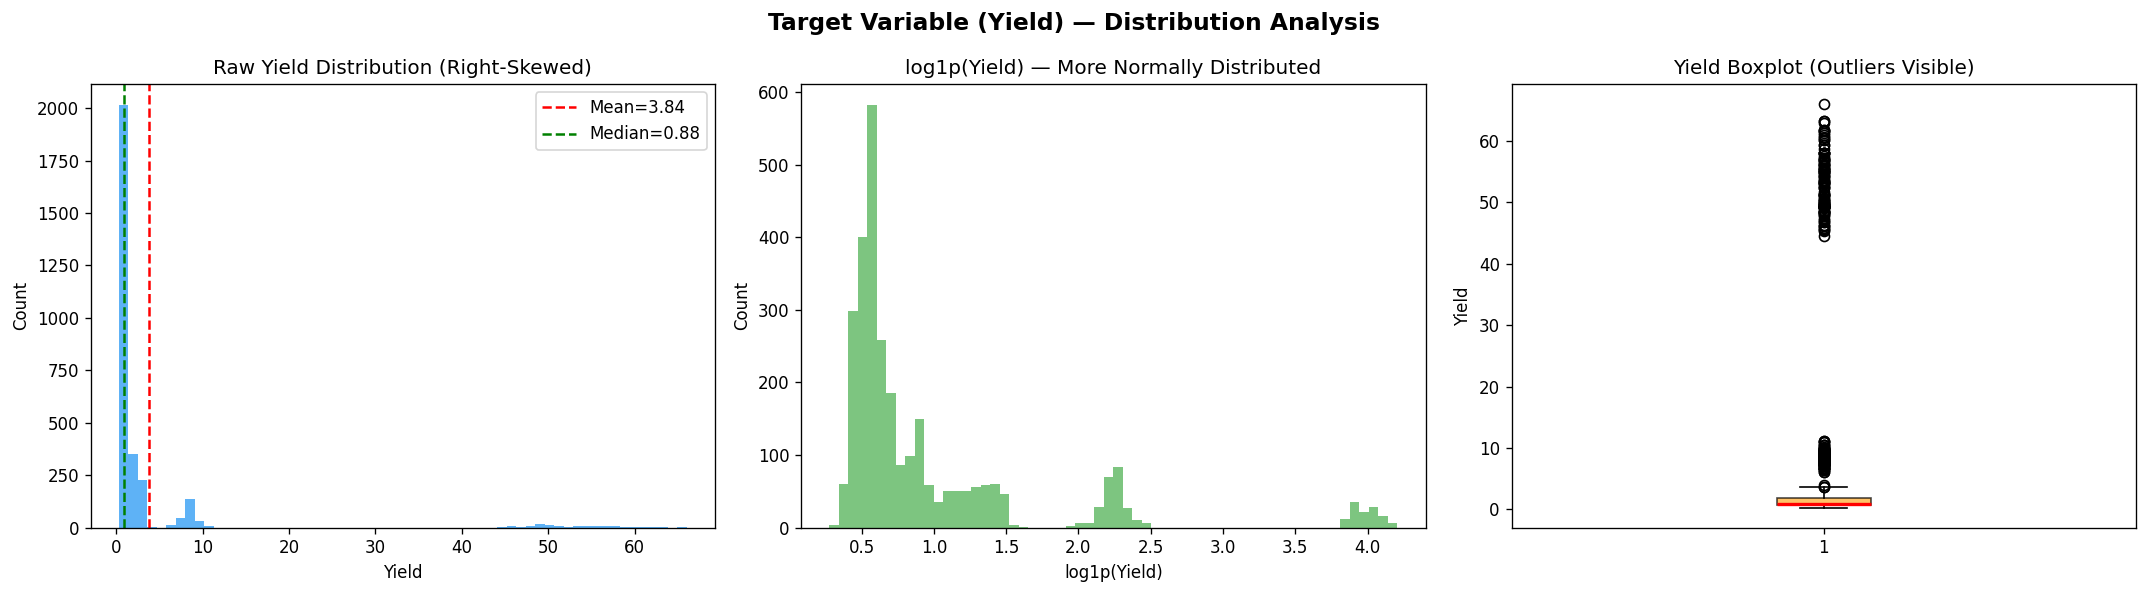

Raw Yield   — Skewness: 4.430  Kurtosis: 18.650
Log Yield   — Skewness: 2.485  Kurtosis: 6.128
→ log1p transformation significantly reduces skewness.


In [86]:
# ── Target variable distribution ─────────────────────────────────────────────
yield_col = 'Yield (Tonne or Bales/Hectare)'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable (Yield) — Distribution Analysis', fontsize=14, fontweight='bold')

# Raw distribution
axes[0].hist(df[yield_col], bins=60, color='#42A5F5', edgecolor='none', alpha=0.85)
axes[0].axvline(df[yield_col].mean(), color='red', linestyle='--', label=f'Mean={df[yield_col].mean():.2f}')
axes[0].axvline(df[yield_col].median(), color='green', linestyle='--', label=f'Median={df[yield_col].median():.2f}')
axes[0].set_title('Raw Yield Distribution (Right-Skewed)')
axes[0].set_xlabel('Yield'); axes[0].set_ylabel('Count')
axes[0].legend()

# Log transform
log_yield = np.log1p(df[yield_col])
axes[1].hist(log_yield, bins=60, color='#66BB6A', edgecolor='none', alpha=0.85)
axes[1].set_title('log1p(Yield) — More Normally Distributed')
axes[1].set_xlabel('log1p(Yield)'); axes[1].set_ylabel('Count')

# Box plot
axes[2].boxplot(df[yield_col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#FFA726', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Yield Boxplot (Outliers Visible)')
axes[2].set_ylabel('Yield')

plt.tight_layout()
plt.show()

from scipy.stats import skew, kurtosis
print(f'Raw Yield   — Skewness: {skew(df[yield_col]):.3f}  Kurtosis: {kurtosis(df[yield_col]):.3f}')
print(f'Log Yield   — Skewness: {skew(log_yield):.3f}  Kurtosis: {kurtosis(log_yield):.3f}')
print('→ log1p transformation significantly reduces skewness.')

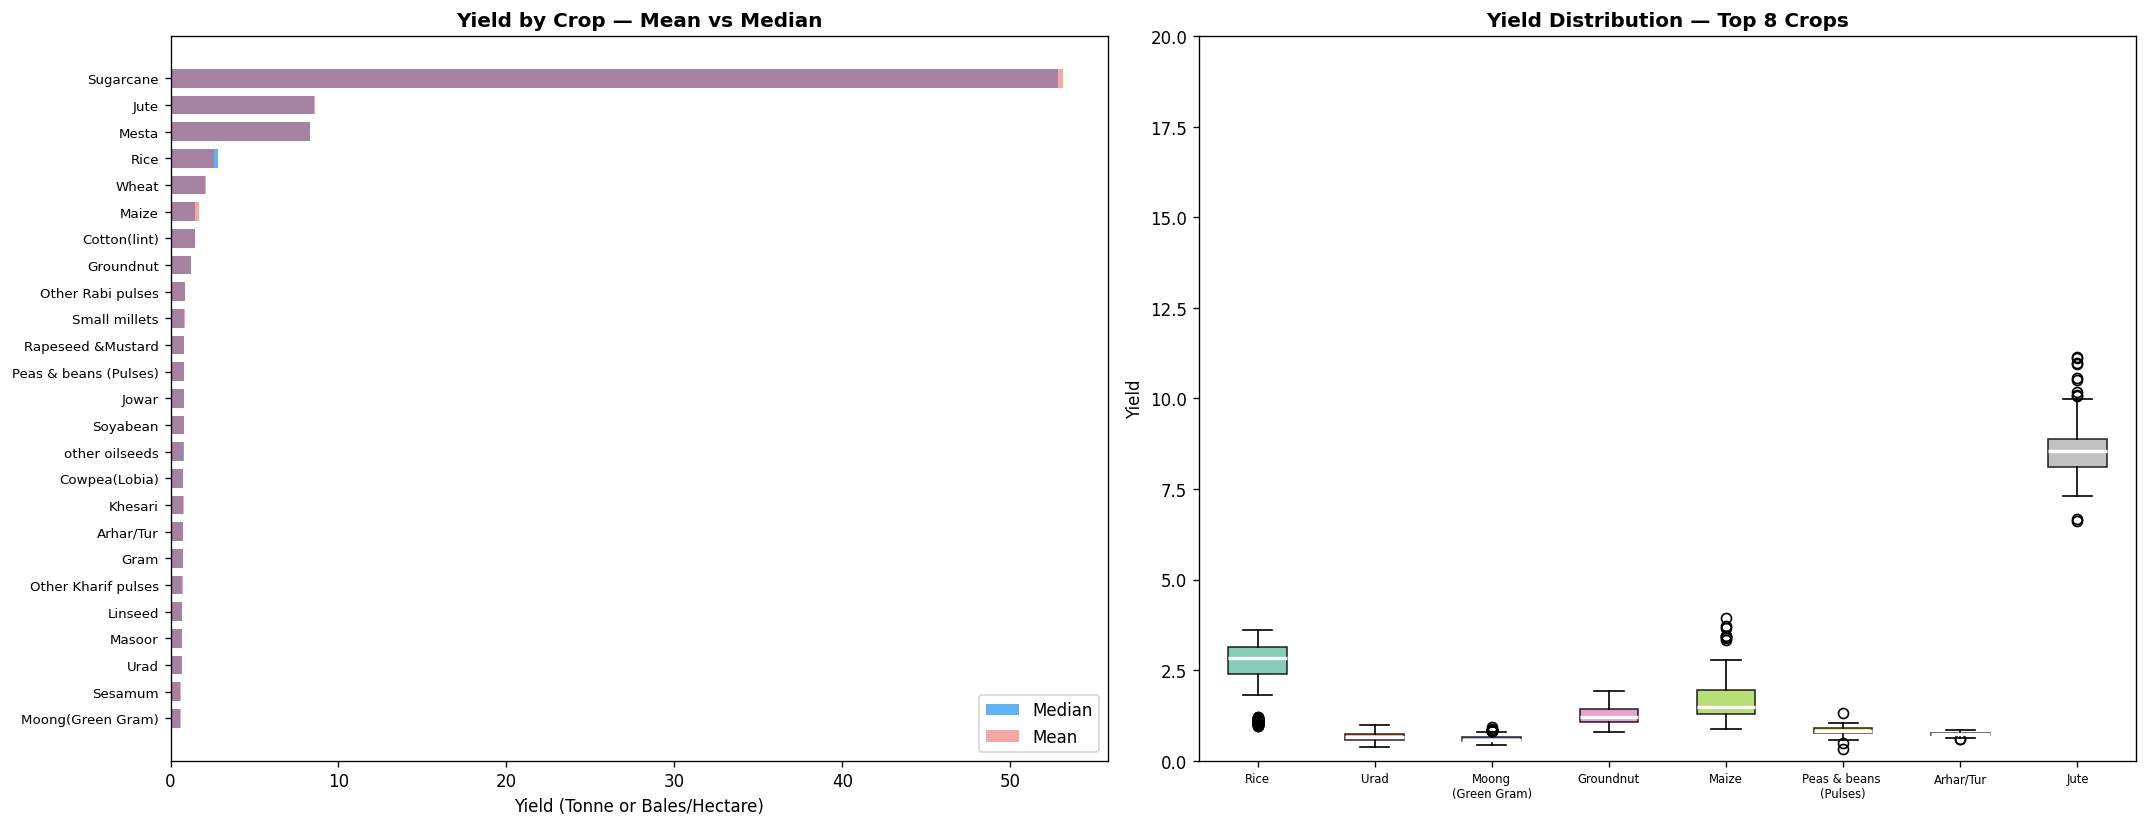

In [87]:
# ── Yield by Crop ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

crop_stats = df.groupby('Crop')[yield_col].agg(['mean','median','std']).sort_values('median', ascending=True)
y_pos = range(len(crop_stats))

axes[0].barh(crop_stats.index, crop_stats['median'], color='#42A5F5', alpha=0.85, height=0.7, label='Median')
axes[0].barh(crop_stats.index, crop_stats['mean'], color='#EF5350', alpha=0.5, height=0.7, label='Mean')
axes[0].set_title('Yield by Crop — Mean vs Median', fontweight='bold')
axes[0].set_xlabel('Yield (Tonne or Bales/Hectare)')
axes[0].legend()
axes[0].tick_params(axis='y', labelsize=8)

# Boxplot per crop (top 10 by count)
top_crops = df['Crop'].value_counts().head(8).index.tolist()
crop_data = [df[df['Crop']==c][yield_col].values for c in top_crops]
bp = axes[1].boxplot(crop_data, labels=[c.replace('(','\n(') for c in top_crops],
                     patch_artist=True, medianprops=dict(color='white', linewidth=2))
colors = plt.cm.Set2(np.linspace(0, 1, len(top_crops)))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.8)
axes[1].set_title('Yield Distribution — Top 8 Crops', fontweight='bold')
axes[1].set_ylabel('Yield')
axes[1].tick_params(axis='x', labelsize=7)
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

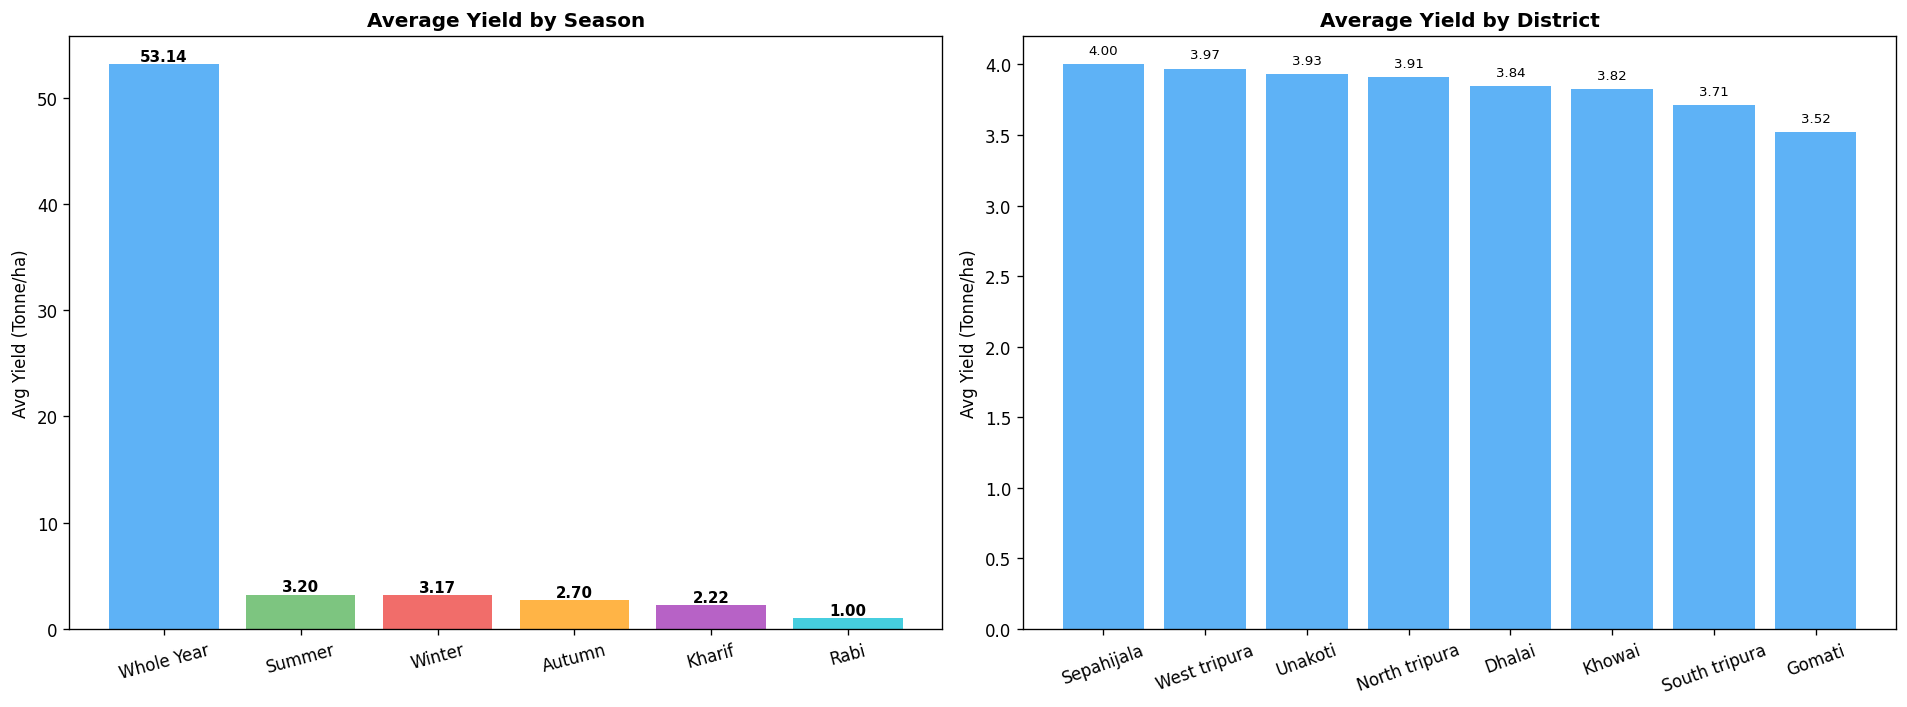

In [88]:
# ── Yield by Season & District ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Season
season_yield = df.groupby('Season')[yield_col].mean().sort_values(ascending=False)
colors_s = ['#42A5F5','#66BB6A','#EF5350','#FFA726','#AB47BC','#26C6DA']
bars = axes[0].bar(season_yield.index, season_yield.values, color=colors_s[:len(season_yield)], alpha=0.85, edgecolor='none')
for bar, val in zip(bars, season_yield.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Average Yield by Season', fontweight='bold')
axes[0].set_ylabel('Avg Yield (Tonne/ha)')
axes[0].tick_params(axis='x', rotation=15)

# By District
dist_yield = df.groupby('District_Name')[yield_col].mean().sort_values(ascending=False)
bars2 = axes[1].bar(dist_yield.index, dist_yield.values, color='#42A5F5', alpha=0.85, edgecolor='none')
for bar, val in zip(bars2, dist_yield.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)
axes[1].set_title('Average Yield by District', fontweight='bold')
axes[1].set_ylabel('Avg Yield (Tonne/ha)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

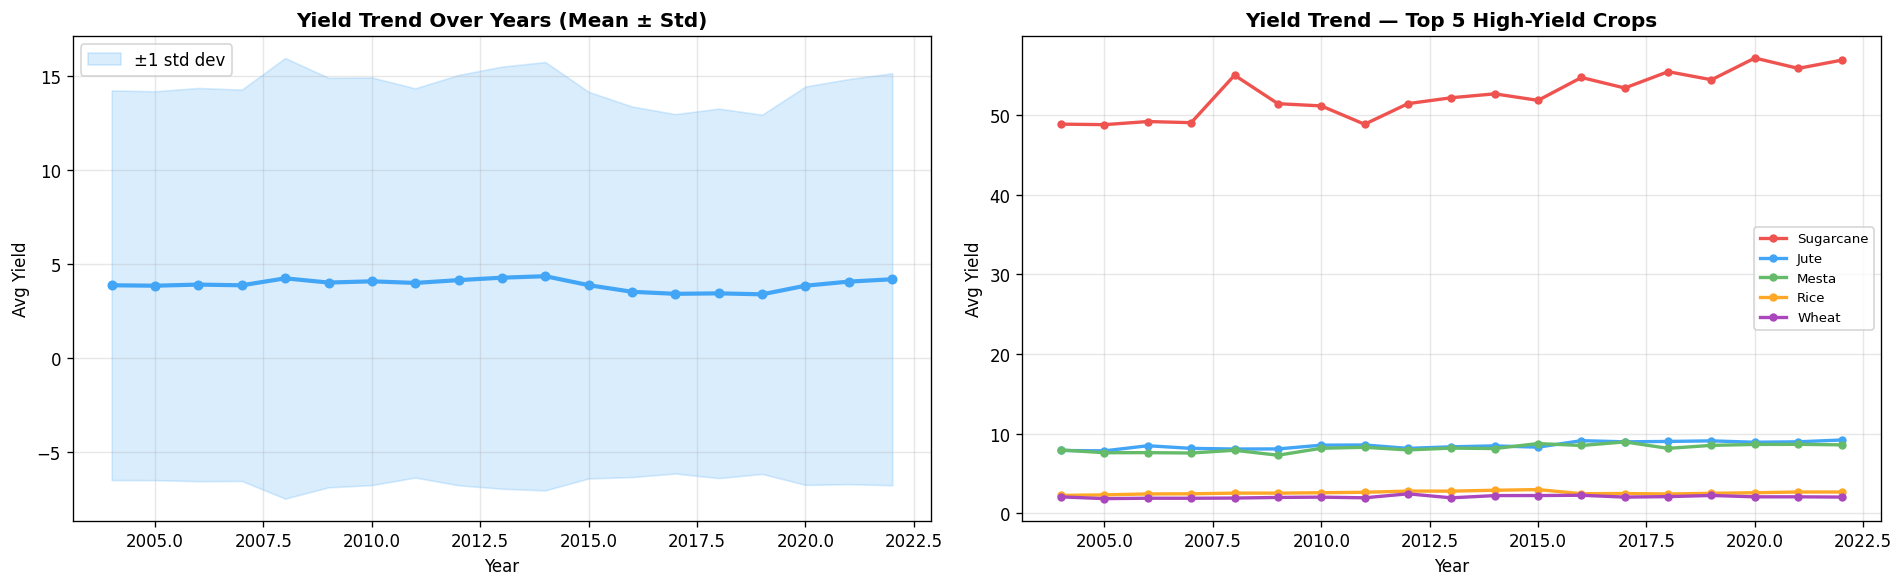

In [89]:
# ── Yield Trend Over Years ────────────────────────────────────────────────────
df['Year_Start'] = df['Crop_Year'].str[:4].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

yr_yield = df.groupby('Year_Start')[yield_col].agg(['mean','std'])
axes[0].plot(yr_yield.index, yr_yield['mean'], color='#42A5F5', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(yr_yield.index,
                     yr_yield['mean'] - yr_yield['std'],
                     yr_yield['mean'] + yr_yield['std'],
                     alpha=0.2, color='#42A5F5', label='±1 std dev')
axes[0].set_title('Yield Trend Over Years (Mean ± Std)', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Avg Yield')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Crop-wise trend for top 5 crops
top5 = df.groupby('Crop')[yield_col].mean().nlargest(5).index.tolist()
colors_t = ['#EF5350','#42A5F5','#66BB6A','#FFA726','#AB47BC']
for crop, c in zip(top5, colors_t):
    cdf = df[df['Crop']==crop].groupby('Year_Start')[yield_col].mean()
    axes[1].plot(cdf.index, cdf.values, color=c, linewidth=2, marker='o', markersize=4, label=crop)
axes[1].set_title('Yield Trend — Top 5 High-Yield Crops', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Avg Yield')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

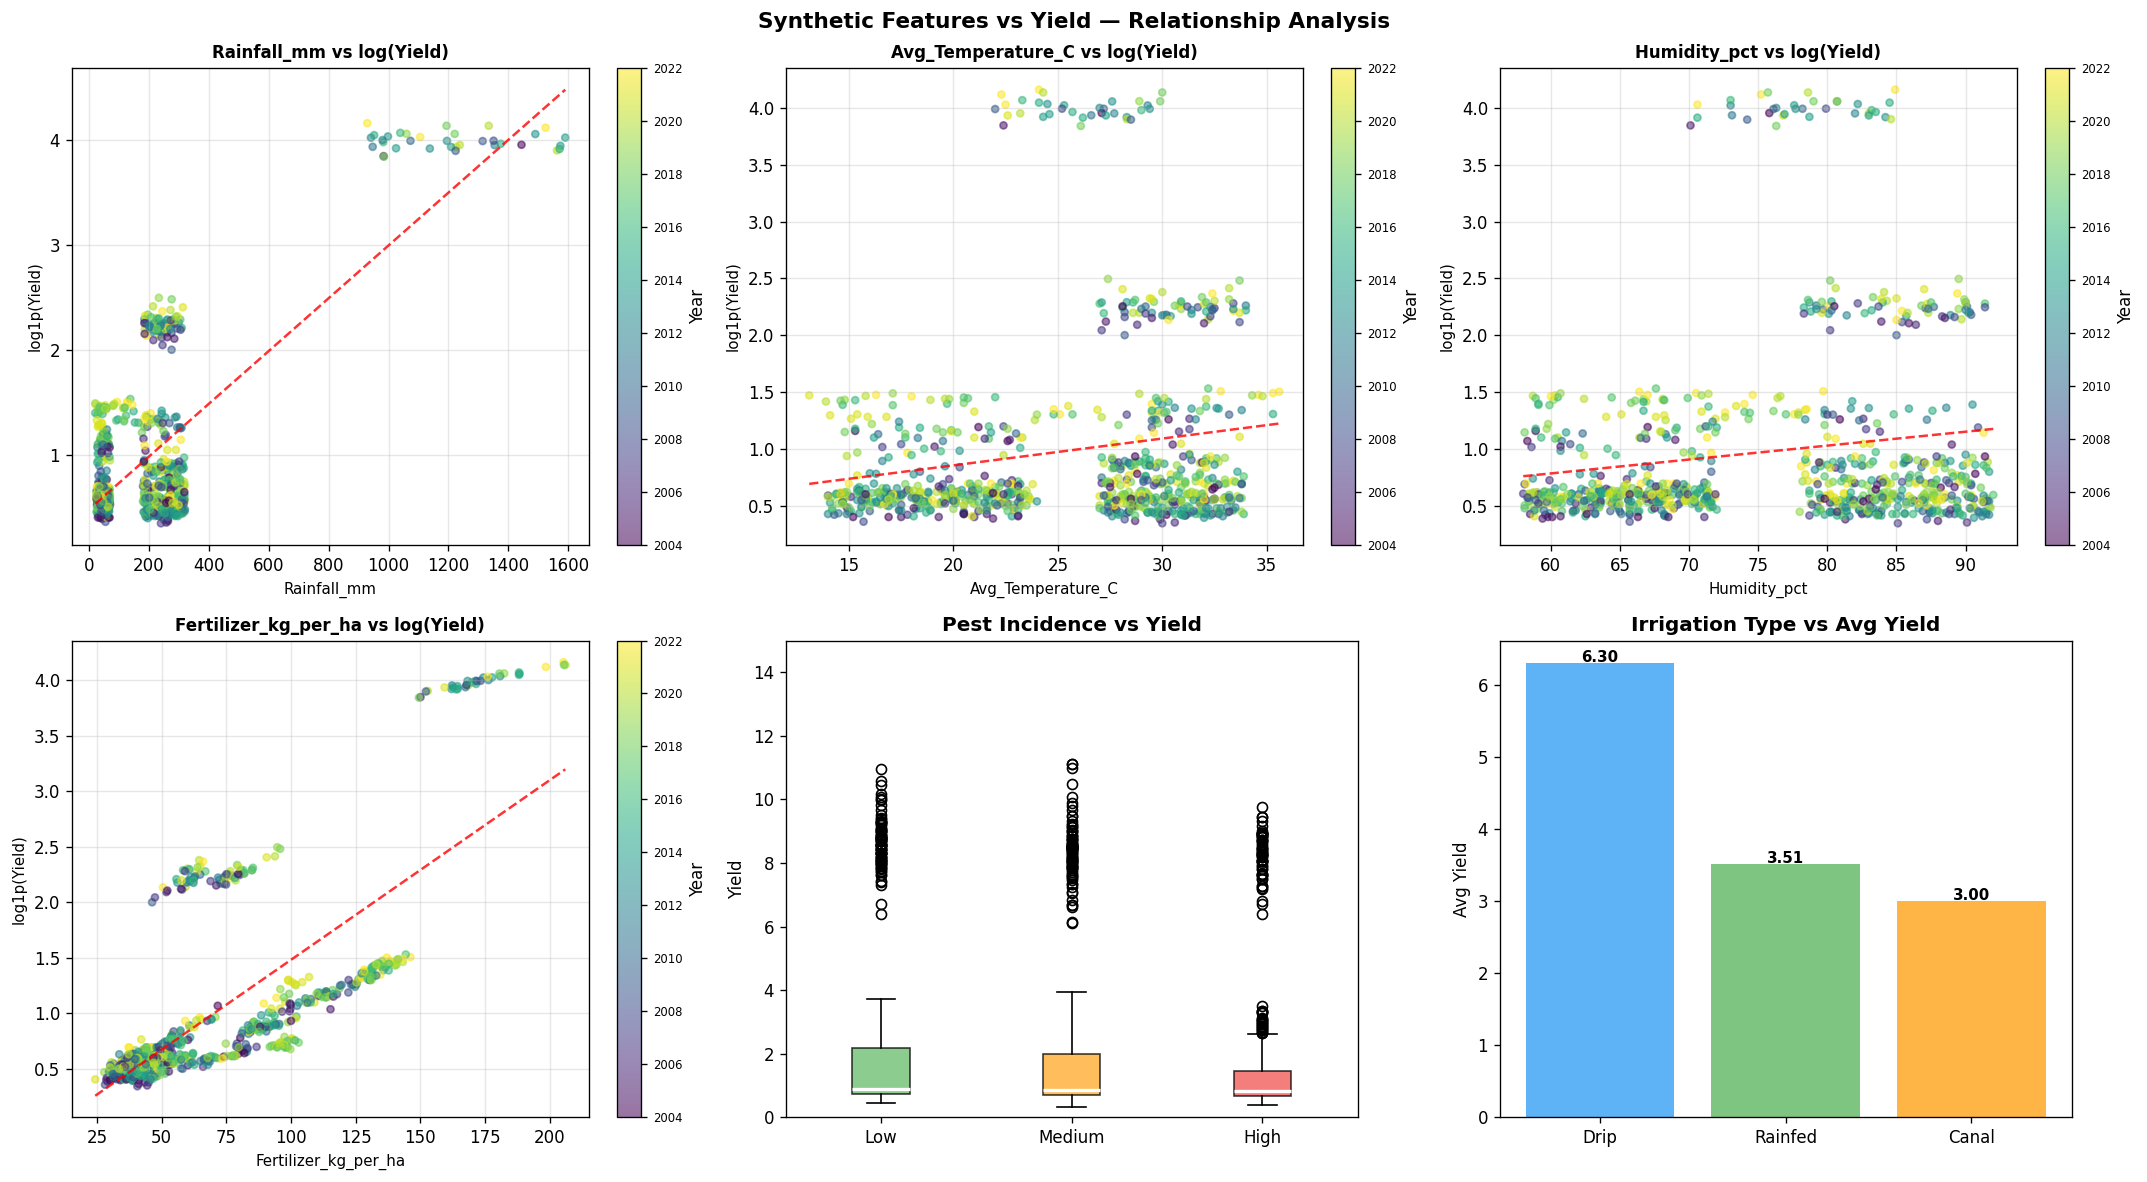

In [90]:
# ── Synthetic Features vs Yield ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Synthetic Features vs Yield — Relationship Analysis', fontsize=13, fontweight='bold')

num_feats = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Fertilizer_kg_per_ha']
sample = df.sample(800, random_state=42)

for i, feat in enumerate(num_feats):
    ax = axes[i//3][i%3] if i < 3 else axes[1][i-3]
    sc = ax.scatter(sample[feat], np.log1p(sample[yield_col]),
                    c=sample['Year_Start'], cmap='viridis', alpha=0.55, s=18)
    # Trend line
    z = np.polyfit(sample[feat], np.log1p(sample[yield_col]), 1)
    p = np.poly1d(z)
    xline = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    ax.plot(xline, p(xline), 'r--', linewidth=1.5, alpha=0.8)
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('log1p(Yield)', fontsize=9)
    ax.set_title(f'{feat} vs log(Yield)', fontweight='bold', fontsize=10)
    plt.colorbar(sc, ax=ax, fraction=0.046, label='Year').ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

# Pest incidence boxplot
pest_order = ['Low','Medium','High']
pest_data = [df[df['Pest_Disease_Incidence']==p][yield_col].values for p in pest_order]
bp = axes[1][1].boxplot(pest_data, labels=pest_order, patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
for patch, c in zip(bp['boxes'], ['#66BB6A','#FFA726','#EF5350']):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[1][1].set_title('Pest Incidence vs Yield', fontweight='bold')
axes[1][1].set_ylabel('Yield'); axes[1][1].set_ylim(0, 15)

# Irrigation type
irr_yield = df.groupby('Irrigation_Type')[yield_col].mean().sort_values(ascending=False)
axes[1][2].bar(irr_yield.index, irr_yield.values,
               color=['#42A5F5','#66BB6A','#FFA726'], alpha=0.85, edgecolor='none')
for i2, (idx, val) in enumerate(irr_yield.items()):
    axes[1][2].text(i2, val+0.02, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1][2].set_title('Irrigation Type vs Avg Yield', fontweight='bold')
axes[1][2].set_ylabel('Avg Yield')

plt.tight_layout()
plt.show()

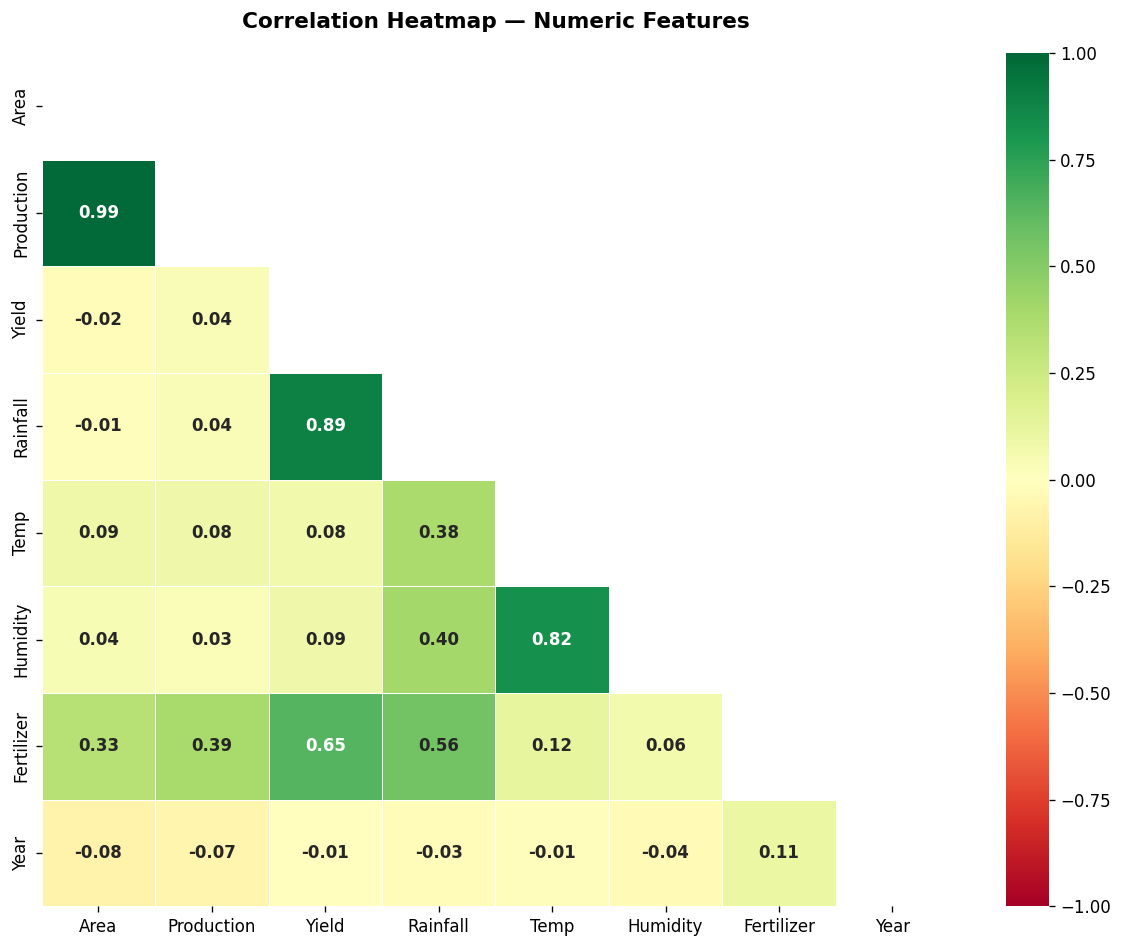


Top correlations with Yield:
Rainfall      0.8917
Fertilizer    0.6480
Humidity      0.0858
Temp          0.0755
Production    0.0375
Area         -0.0237
Year         -0.0078


In [91]:
# ── Correlation Heatmap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

num_cols = ['Area (Hectare)', 'Production (Tonnes/Bales)', yield_col,
            'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
            'Fertilizer_kg_per_ha', 'Year_Start']
short_names = ['Area','Production','Yield','Rainfall','Temp','Humidity','Fertilizer','Year']

corr = df[num_cols].corr()
corr.index   = short_names
corr.columns = short_names

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'},
            vmin=-1, vmax=1, center=0)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nTop correlations with Yield:')
yield_corr = corr['Yield'].drop('Yield').sort_values(key=abs, ascending=False)
print(yield_corr.to_string())

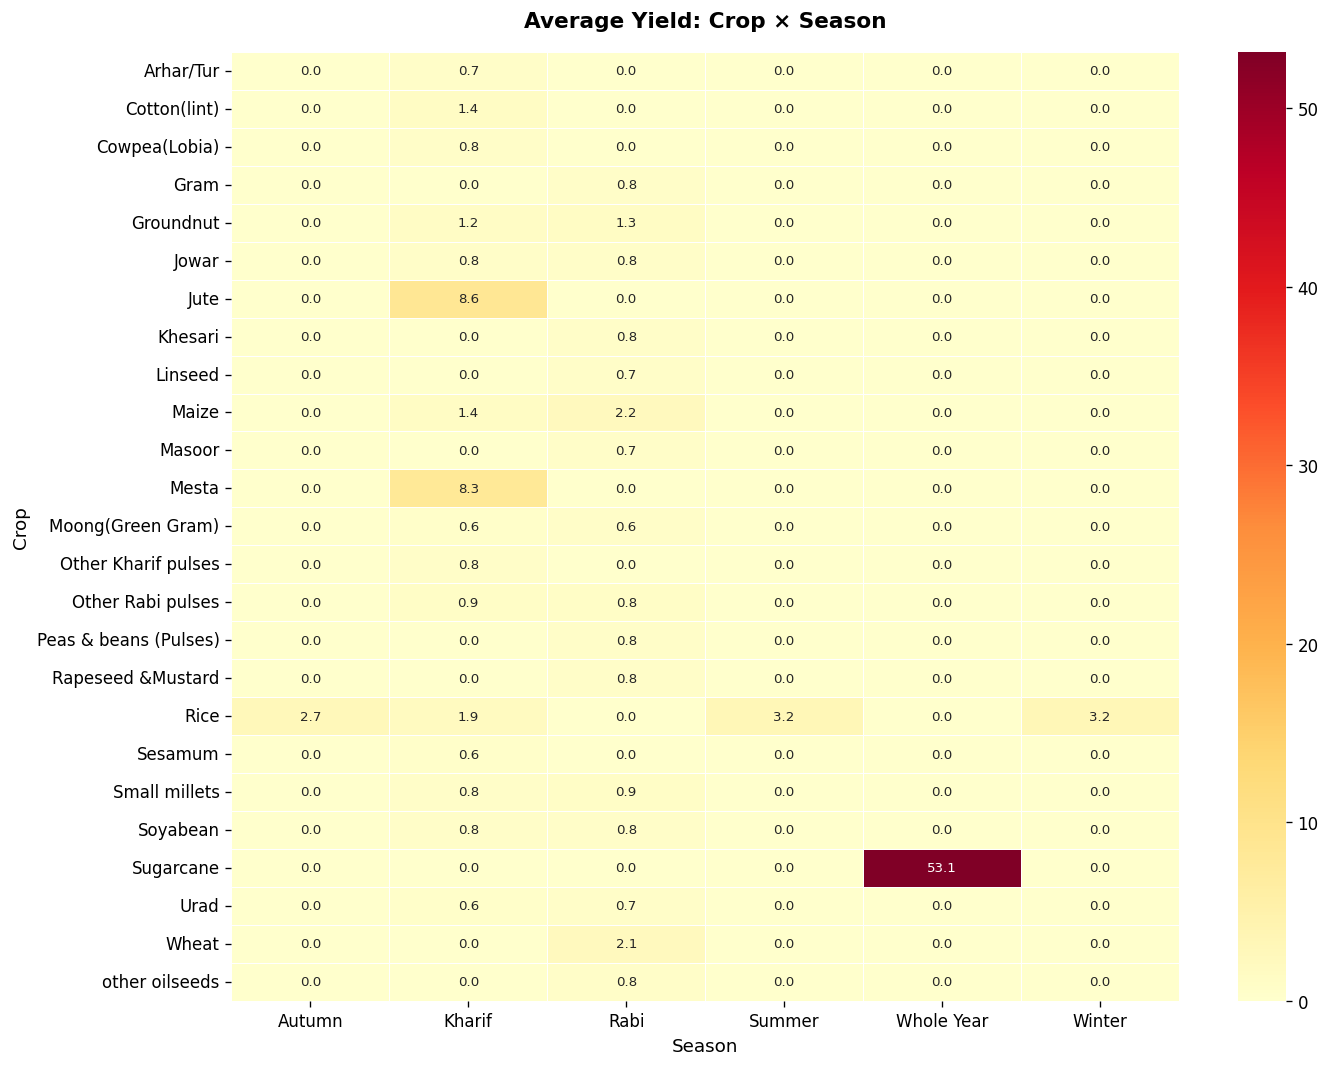

In [92]:
# ── Pivot Heatmap: Crop × Season ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

pivot = df.groupby(['Crop', 'Season'])[yield_col].mean().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Average Yield: Crop × Season', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Crop', fontsize=11)
plt.tight_layout()
plt.show()

## Step 3 — Feature Engineering & Preprocessing

In [93]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df_ml = df.copy()

# 1. Extract numeric year
df_ml['Year_Start'] = df_ml['Crop_Year'].str[:4].astype(int)

# 2. Log-transform target (handles skewness)
df_ml['log_yield'] = np.log1p(df_ml['Yield (Tonne or Bales/Hectare)'])

# 3. Log-transform Area and Production (also skewed)
df_ml['log_area']       = np.log1p(df_ml['Area (Hectare)'])
df_ml['log_production'] = np.log1p(df_ml['Production (Tonnes/Bales)'])

# 4. Encode ordinal feature
pest_order_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_ml['Pest_Ordinal'] = df_ml['Pest_Disease_Incidence'].map(pest_order_map)

# 5. Label encode remaining categoricals
cat_cols = ['District_Name', 'Season', 'Crop', 'Soil_Type', 'Irrigation_Type']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])
    le_dict[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nFeature engineering complete!')
print(f'   New columns added: Year_Start, log_yield, log_area, log_production, Pest_Ordinal, *_enc')

  District_Name: {'Dhalai': np.int64(0), 'Gomati': np.int64(1), 'Khowai': np.int64(2), 'North tripura': np.int64(3), 'Sepahijala': np.int64(4), 'South tripura': np.int64(5), 'Unakoti': np.int64(6), 'West tripura': np.int64(7)}
  Season: {'Autumn': np.int64(0), 'Kharif': np.int64(1), 'Rabi': np.int64(2), 'Summer': np.int64(3), 'Whole Year': np.int64(4), 'Winter': np.int64(5)}
  Crop: {'Arhar/Tur': np.int64(0), 'Cotton(lint)': np.int64(1), 'Cowpea(Lobia)': np.int64(2), 'Gram': np.int64(3), 'Groundnut': np.int64(4), 'Jowar': np.int64(5), 'Jute': np.int64(6), 'Khesari': np.int64(7), 'Linseed': np.int64(8), 'Maize': np.int64(9), 'Masoor': np.int64(10), 'Mesta': np.int64(11), 'Moong(Green Gram)': np.int64(12), 'Other Kharif pulses': np.int64(13), 'Other Rabi pulses': np.int64(14), 'Peas & beans (Pulses)': np.int64(15), 'Rapeseed &Mustard': np.int64(16), 'Rice': np.int64(17), 'Sesamum': np.int64(18), 'Small millets': np.int64(19), 'Soyabean': np.int64(20), 'Sugarcane': np.int64(21), 'Urad': n

In [94]:
# ── Define Feature Set ────────────────────────────────────────────────────────
feature_cols = [
    # Encoded categoricals
    'District_Name_enc', 'Season_enc', 'Crop_enc',
    'Soil_Type_enc', 'Irrigation_Type_enc', 'Pest_Ordinal',
    # Numeric originals
    'log_area', 'Rainfall_mm', 'Avg_Temperature_C',
    'Humidity_pct', 'Fertilizer_kg_per_ha', 'Year_Start'
]

TARGET = 'log_yield'

X = df_ml[feature_cols]
y = df_ml[TARGET]

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')
print(f'\nFeatures used ({len(feature_cols)}):')
for i, f in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {f}')

Feature matrix X: (2955, 12)
Target vector  y: (2955,)

Features used (12):
   1. District_Name_enc
   2. Season_enc
   3. Crop_enc
   4. Soil_Type_enc
   5. Irrigation_Type_enc
   6. Pest_Ordinal
   7. log_area
   8. Rainfall_mm
   9. Avg_Temperature_C
  10. Humidity_pct
  11. Fertilizer_kg_per_ha
  12. Year_Start


## Step 4 — ML Pipeline Diagram

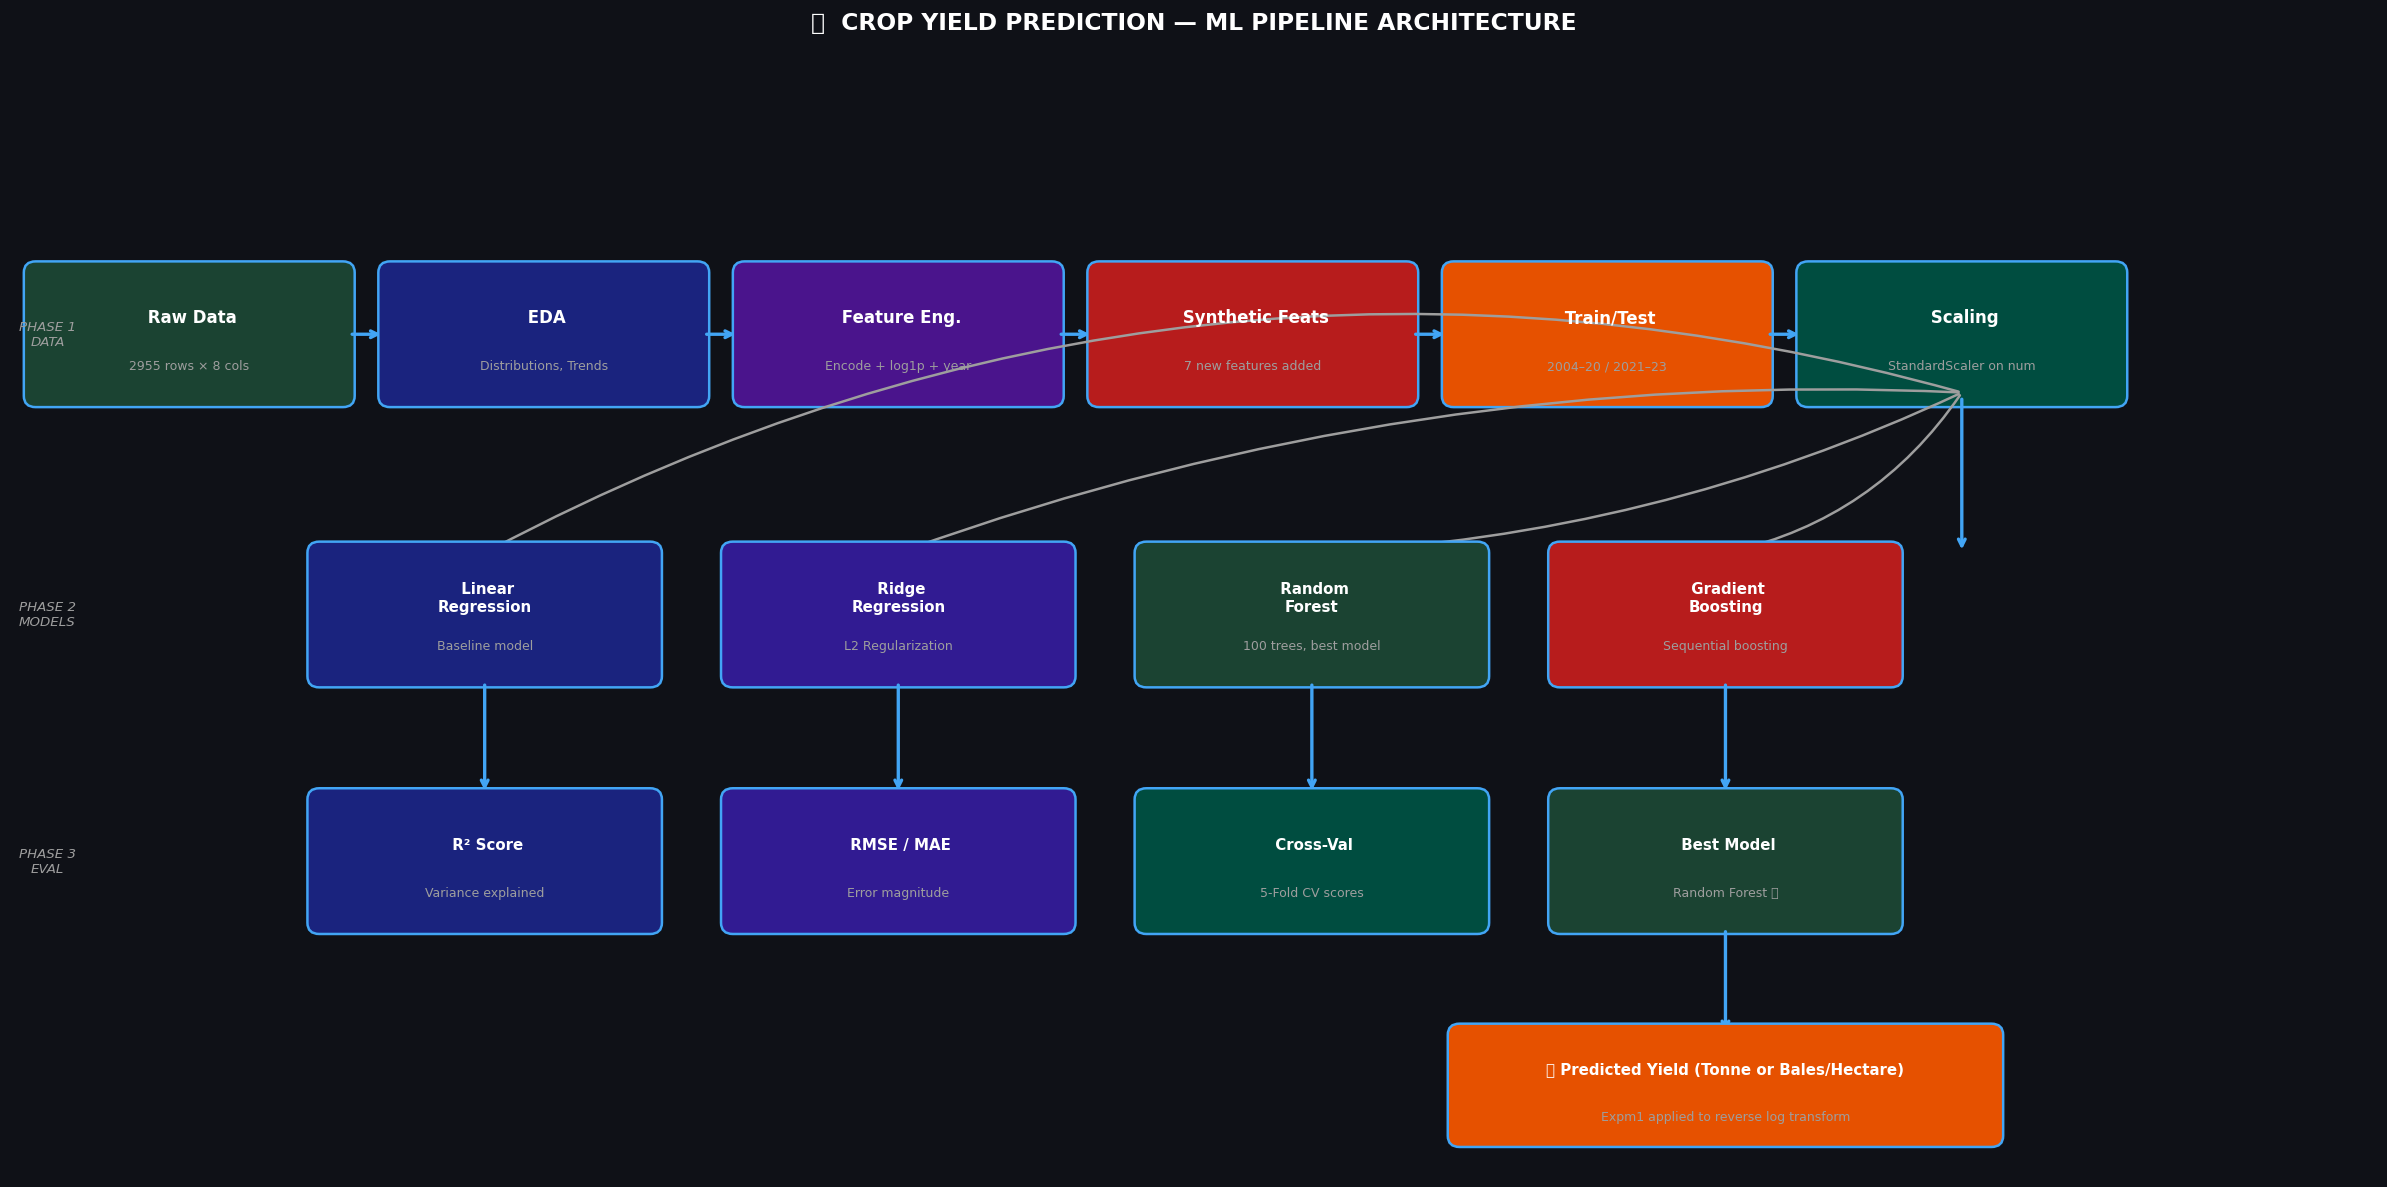

✅ Pipeline diagram saved as ml_pipeline_architecture.png


In [95]:
# ── Draw Full ML Pipeline ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 10))
ax.set_xlim(0, 20)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#0F1117')
fig.patch.set_facecolor('#0F1117')

def draw_box(ax, x, y, w, h, label, sublabel='', color='#1E3A5F', text_color='white', fontsize=10):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.1',
                          facecolor=color, edgecolor='#42A5F5',
                          linewidth=1.5, zorder=3)
    ax.add_patch(box)
    ax.text(x, y + (0.15 if sublabel else 0), label,
            ha='center', va='center', color=text_color,
            fontsize=fontsize, fontweight='bold', zorder=4)
    if sublabel:
        ax.text(x, y - 0.28, sublabel,
                ha='center', va='center', color='#9E9E9E',
                fontsize=7.5, zorder=4)

def draw_arrow(ax, x1, x2, y, color='#42A5F5'):
    ax.annotate('', xy=(x2 - 0.05, y), xytext=(x1 + 0.05, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

def draw_arrow_down(ax, x, y1, y2, color='#42A5F5'):
    ax.annotate('', xy=(x, y2 + 0.05), xytext=(x, y1 - 0.05),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

# ── Row 1: Data Flow ──────────────────────────────────────────────────────────
steps_r1 = [
    (1.5,  7.5, ' Raw Data',        '2955 rows × 8 cols',    '#1B4332'),
    (4.5,  7.5, ' EDA',             'Distributions, Trends', '#1A237E'),
    (7.5,  7.5, ' Feature Eng.',    'Encode + log1p + year', '#4A148C'),
    (10.5, 7.5, ' Synthetic Feats', '7 new features added',  '#B71C1C'),
    (13.5, 7.5, ' Train/Test',      '2004–20 / 2021–23',     '#E65100'),
    (16.5, 7.5, ' Scaling',         'StandardScaler on num', '#004D40'),
]
for x, y2, label, sub, color in steps_r1:
    draw_box(ax, x, y2, 2.6, 1.1, label, sub, color=color)
for i in range(len(steps_r1)-1):
    draw_arrow(ax, steps_r1[i][0]+1.3, steps_r1[i+1][0]-1.3, 7.5)

# ── Row 2: Models ─────────────────────────────────────────────────────────────
draw_arrow_down(ax, 16.5, 7.0, 5.5)

models_r2 = [
    (4.0,  5.0, ' Linear\nRegression',  'Baseline model',       '#1A237E'),
    (7.5,  5.0, ' Ridge\nRegression',   'L2 Regularization',    '#311B92'),
    (11.0, 5.0, ' Random\nForest',      '100 trees, best model','#1B4332'),
    (14.5, 5.0, ' Gradient\nBoosting',  'Sequential boosting',  '#B71C1C'),
]

# Funnel from train/test to models
ax.annotate('', xy=(4.0, 5.55), xytext=(16.5, 6.98),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=1.5, connectionstyle='arc3,rad=0.2'))
ax.annotate('', xy=(7.5, 5.55), xytext=(16.5, 6.98),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=1.5, connectionstyle='arc3,rad=0.1'))
ax.annotate('', xy=(11.0, 5.55), xytext=(16.5, 6.98),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=1.5, connectionstyle='arc3,rad=-0.1'))
ax.annotate('', xy=(14.5, 5.55), xytext=(16.5, 6.98),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=1.5, connectionstyle='arc3,rad=-0.2'))

for x, y2, label, sub, color in models_r2:
    draw_box(ax, x, y2, 2.8, 1.1, label, sub, color=color, fontsize=9)

# ── Row 3: Evaluation ─────────────────────────────────────────────────────────
eval_steps = [
    (4.0,  2.8, ' R² Score',       'Variance explained',   '#1A237E'),
    (7.5,  2.8, ' RMSE / MAE',     'Error magnitude',      '#311B92'),
    (11.0, 2.8, ' Cross-Val',      '5-Fold CV scores',     '#004D40'),
    (14.5, 2.8, ' Best Model',     'Random Forest ✅',      '#1B4332'),
]
for (mx, my, _, _, _), (ex, ey, label, sub, color) in zip(models_r2, eval_steps):
    draw_arrow_down(ax, mx, my - 0.55, ey + 0.55)
    draw_box(ax, ex, ey, 2.8, 1.1, label, sub, color=color, fontsize=9)

# ── Row 4: Output ─────────────────────────────────────────────────────────────
draw_arrow_down(ax, 14.5, 2.25, 1.2)
draw_box(ax, 14.5, 0.8, 4.5, 0.9, '🌾 Predicted Yield (Tonne or Bales/Hectare)',
         'Expm1 applied to reverse log transform', color='#E65100', fontsize=9)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.text(0.3, 7.5, 'PHASE 1\nDATA', color='#9E9E9E', fontsize=8, va='center', ha='center', style='italic')
ax.text(0.3, 5.0, 'PHASE 2\nMODELS', color='#9E9E9E', fontsize=8, va='center', ha='center', style='italic')
ax.text(0.3, 2.8, 'PHASE 3\nEVAL', color='#9E9E9E', fontsize=8, va='center', ha='center', style='italic')

ax.set_title('🌾  CROP YIELD PREDICTION — ML PIPELINE ARCHITECTURE',
             color='white', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('ml_pipeline_architecture.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Pipeline diagram saved as ml_pipeline_architecture.png')

## Step 5 — Train / Test Split (Time-Based)

In [96]:
# ── Time-based split — NO data leakage ──────────────────────────────────────
TRAIN_CUTOFF = 2020  # Train: 2004–2020 | Test: 2021–2023

train_mask = df_ml['Year_Start'] <= TRAIN_CUTOFF
test_mask  = df_ml['Year_Start'] >  TRAIN_CUTOFF

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print('=' * 45)
print(f'Training Set  : {X_train.shape[0]:>5} rows | 2004–2020')
print(f'Test Set      : {X_test.shape[0]:>5} rows | 2021–2023')
print(f'Train %       : {len(X_train)/(len(X_train)+len(X_test))*100:.1f}%')
print(f'Test  %       : {len(X_test)/(len(X_train)+len(X_test))*100:.1f}%')
print('=' * 45)

# ── Scale numeric features ───────────────────────────────────────────────────
numeric_feats = ['log_area','Rainfall_mm','Avg_Temperature_C',
                 'Humidity_pct','Fertilizer_kg_per_ha','Year_Start']
scaler = StandardScaler()

X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test_s[numeric_feats]  = scaler.transform(X_test[numeric_feats])

print('\n Train/Test split & scaling done!')

Training Set  :  2547 rows | 2004–2020
Test Set      :   408 rows | 2021–2023
Train %       : 86.2%
Test  %       : 13.8%

 Train/Test split & scaling done!


##  Step 6 — Model Building & Training

In [97]:
# ── Train All Models ──────────────────────────────────────────────────────────
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, max_depth=None,
                                                 min_samples_split=2, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                      max_depth=4, random_state=42),
}

results = {}
print('Training models...\n')

for name, model in models.items():
    # Use scaled X for linear models, unscaled for tree models
    Xtr = X_train_s if 'Regression' in name else X_train
    Xte = X_test_s  if 'Regression' in name else X_test

    model.fit(Xtr, y_train)
    pred_log = model.predict(Xte)

    # Reverse log transform
    pred_orig = np.expm1(pred_log)
    true_orig = np.expm1(y_test)

    r2   = r2_score(y_test, pred_log)
    rmse = np.sqrt(mean_squared_error(true_orig, pred_orig))
    mae  = mean_absolute_error(true_orig, pred_orig)
    mape = mean_absolute_percentage_error(true_orig, pred_orig) * 100

    results[name] = {
        'model': model, 'pred_log': pred_log,
        'pred_orig': pred_orig, 'true_orig': true_orig,
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape
    }
    print(f'  {name:<22} R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%')

print('\n All models trained!')

Training models...

  Linear Regression      R²=0.7732  RMSE=5.1968  MAE=1.7094  MAPE=36.63%
  Ridge Regression       R²=0.7732  RMSE=5.1883  MAE=1.7081  MAPE=36.62%
  Random Forest          R²=0.9879  RMSE=0.4162  MAE=0.1708  MAPE=7.55%
  Gradient Boosting      R²=0.9926  RMSE=0.3698  MAE=0.1911  MAPE=8.17%

 All models trained!


## 
 Step 7 — Model Evaluation

In [98]:
# ── Model Comparison Table ────────────────────────────────────────────────────
eval_df = pd.DataFrame({
    'Model':  list(results.keys()),
    'R²':     [results[m]['R2']   for m in results],
    'RMSE':   [results[m]['RMSE'] for m in results],
    'MAE':    [results[m]['MAE']  for m in results],
    'MAPE %': [results[m]['MAPE'] for m in results],
}).sort_values('R²', ascending=False).reset_index(drop=True)

print('=' * 65)
print('MODEL COMPARISON TABLE')
print('=' * 65)
print(eval_df.to_string(index=False))
print('=' * 65)
best_model_name = eval_df.iloc[0]['Model']
print(f'\n Best Model: {best_model_name} (R²={eval_df.iloc[0]["R²"]:.4f})')

MODEL COMPARISON TABLE
            Model     R²   RMSE    MAE  MAPE %
Gradient Boosting 0.9926 0.3698 0.1911  8.1747
    Random Forest 0.9879 0.4162 0.1708  7.5484
 Ridge Regression 0.7732 5.1883 1.7081 36.6235
Linear Regression 0.7732 5.1968 1.7094 36.6281

 Best Model: Gradient Boosting (R²=0.9926)


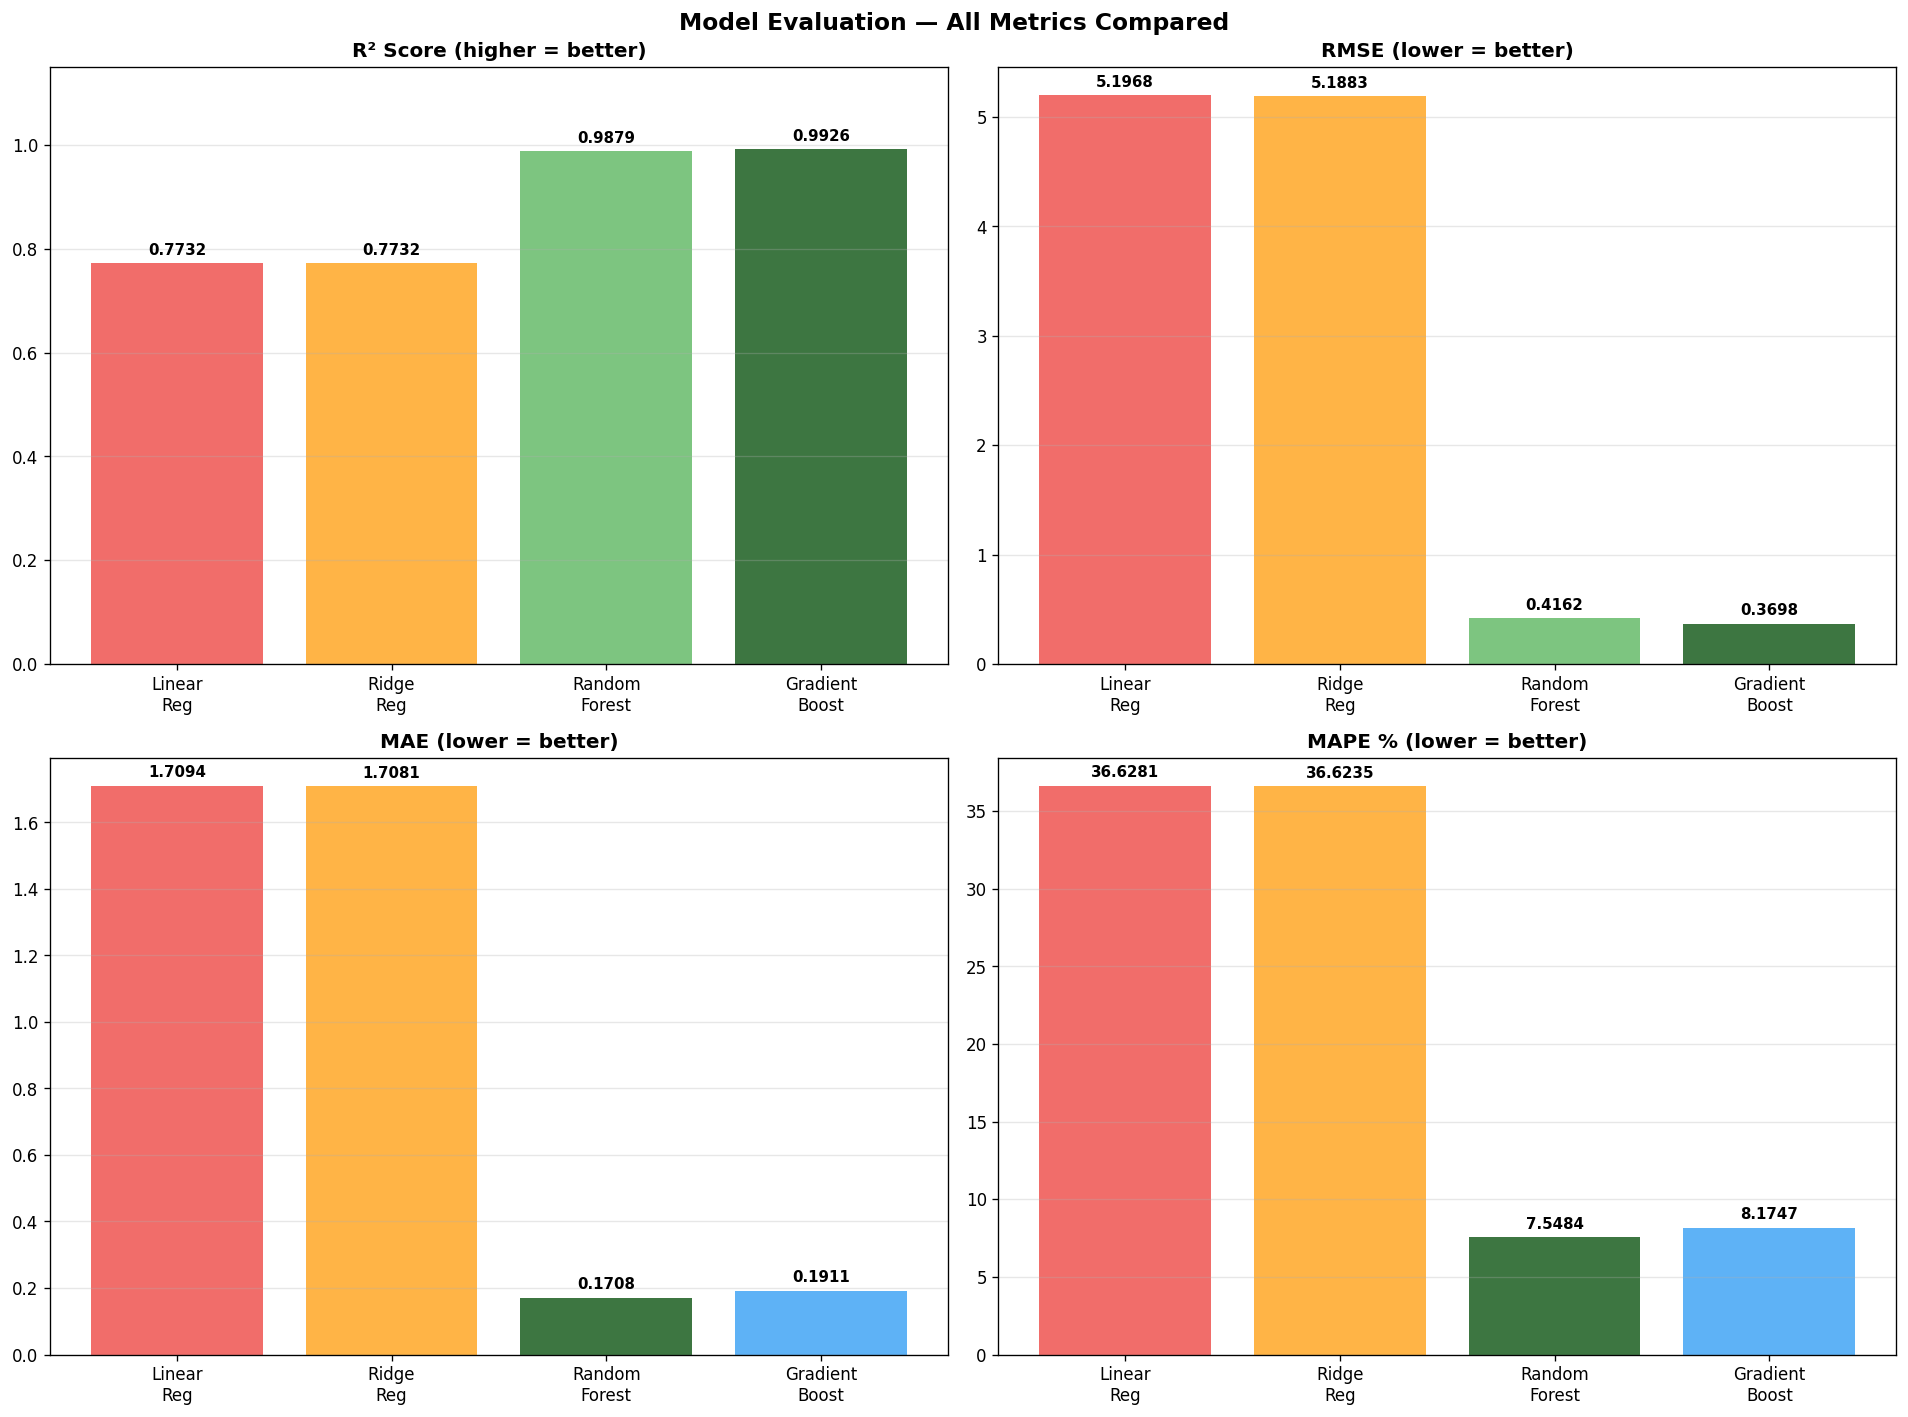

In [99]:
# ── Evaluation Charts ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Evaluation — All Metrics Compared', fontsize=14, fontweight='bold')

model_names = list(results.keys())
short_names = ['Linear\nReg', 'Ridge\nReg', 'Random\nForest', 'Gradient\nBoost']
bar_colors  = ['#EF5350','#FFA726','#66BB6A','#42A5F5']

metrics = ['R2', 'RMSE', 'MAE', 'MAPE']
titles  = ['R² Score (higher = better)', 'RMSE (lower = better)',
           'MAE (lower = better)', 'MAPE % (lower = better)']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    vals = [results[m][metric] for m in model_names]
    best_idx = np.argmax(vals) if metric == 'R2' else np.argmin(vals)
    colors = [('#1B5E20' if i == best_idx else c) for i, c in enumerate(bar_colors)]
    bars = ax.bar(short_names, vals, color=colors, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    if metric == 'R2': ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

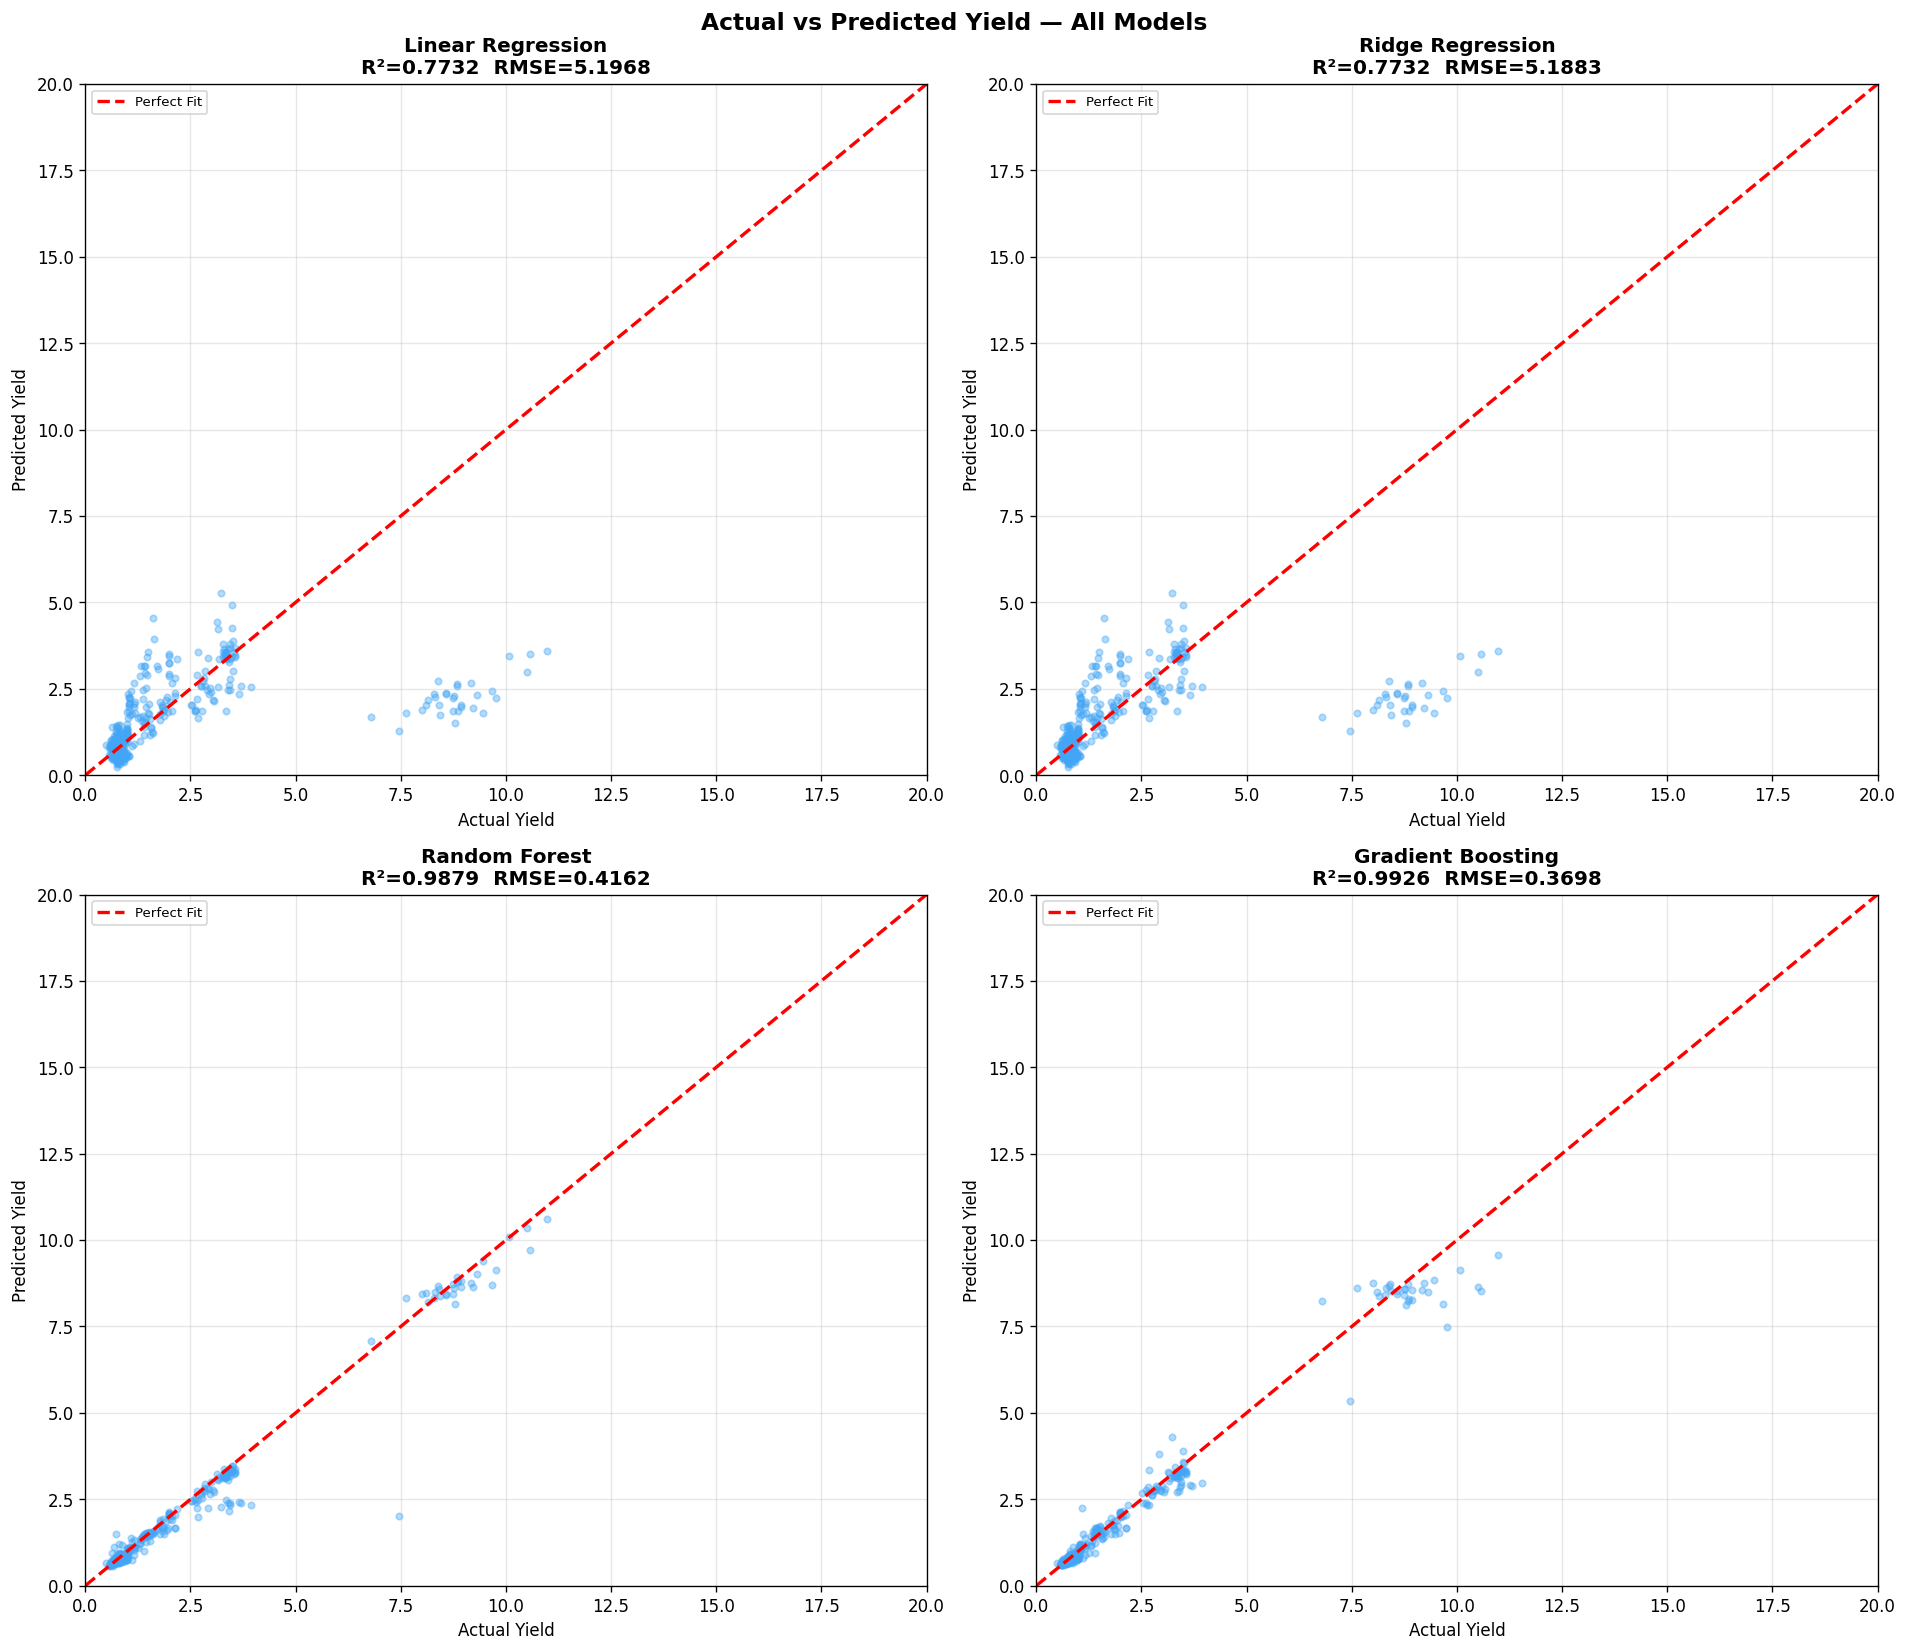

In [100]:
# ── Actual vs Predicted — All Models ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Actual vs Predicted Yield — All Models', fontsize=14, fontweight='bold')

for ax, name in zip(axes.flatten(), model_names):
    true_v = results[name]['true_orig'].values
    pred_v = results[name]['pred_orig']

    # Clip for visibility
    mask = true_v < 20
    ax.scatter(true_v[mask], pred_v[mask], alpha=0.4, s=15, color='#42A5F5')
    lim = 20
    ax.plot([0, lim], [0, lim], 'r--', linewidth=2, label='Perfect Fit')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f'{name}\nR²={results[name]["R2"]:.4f}  RMSE={results[name]["RMSE"]:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Actual Yield'); ax.set_ylabel('Predicted Yield')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

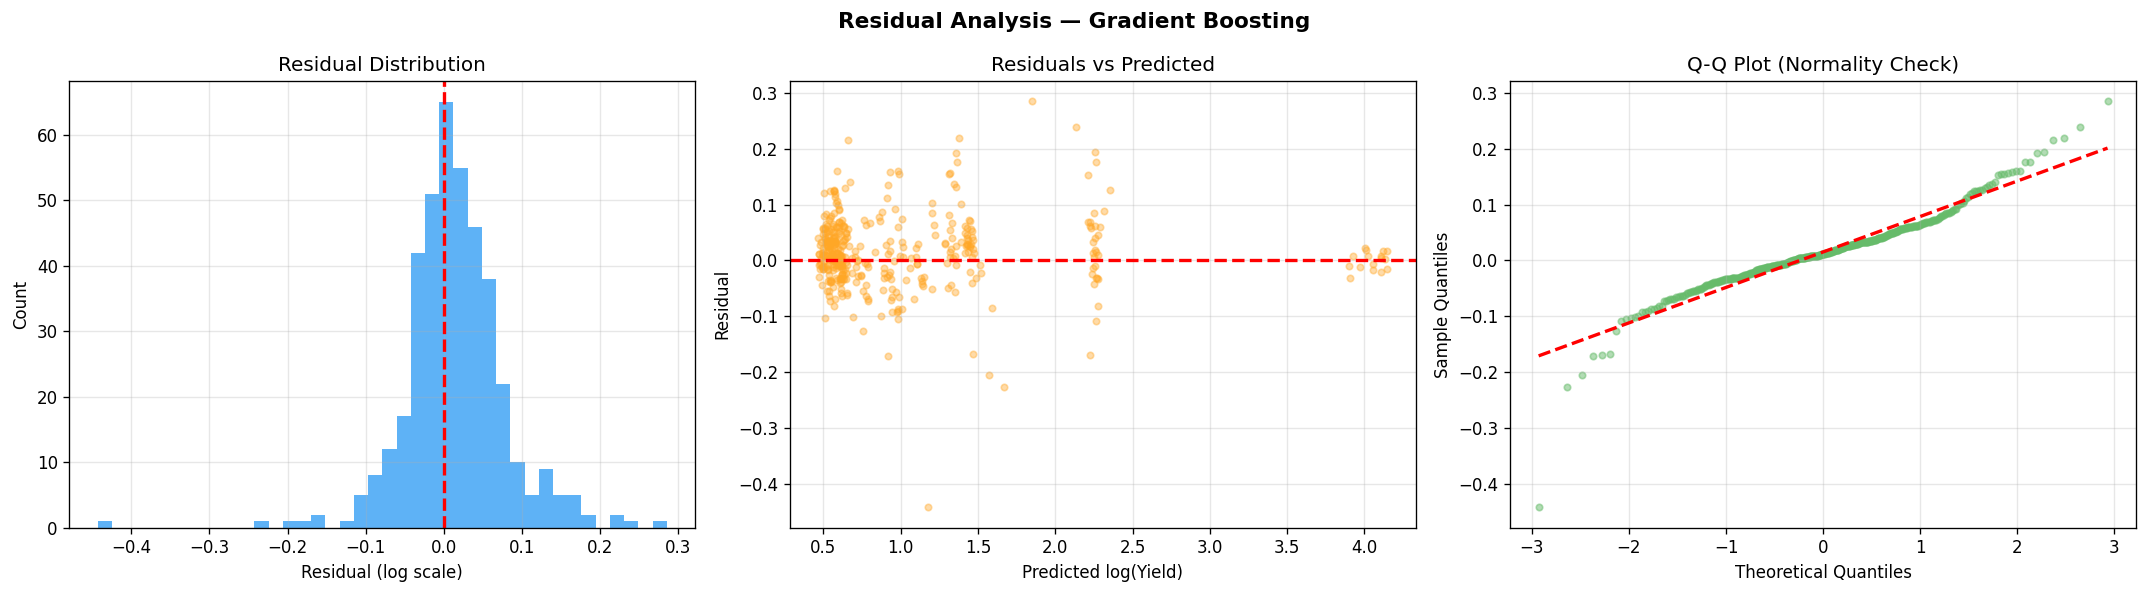

Residual Mean  : 0.015147  (should be ≈ 0)
Residual Std   : 0.065974
Residual Range : [-0.4425, 0.2851]


In [101]:
# ── Residual Analysis ─────────────────────────────────────────────────────────
best_name = best_model_name
pred_log  = results[best_name]['pred_log']
residuals = y_test.values - pred_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')

# Residual distribution
axes[0].hist(residuals, bins=40, color='#42A5F5', edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (log scale)'); axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(pred_log, residuals, alpha=0.4, s=15, color='#FFA726')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted log(Yield)'); axes[1].set_ylabel('Residual')
axes[1].grid(alpha=0.3)

# Q-Q plot
from scipy.stats import probplot
(osm, osr), (slope, intercept, r) = probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, alpha=0.5, s=15, color='#66BB6A')
axes[2].plot(osm, slope*np.array(osm)+intercept, 'r--', linewidth=2)
axes[2].set_title('Q-Q Plot (Normality Check)')
axes[2].set_xlabel('Theoretical Quantiles'); axes[2].set_ylabel('Sample Quantiles')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Residual Mean  : {residuals.mean():.6f}  (should be ≈ 0)')
print(f'Residual Std   : {residuals.std():.6f}')
print(f'Residual Range : [{residuals.min():.4f}, {residuals.max():.4f}]')

##  Step 8 — Feature Importance

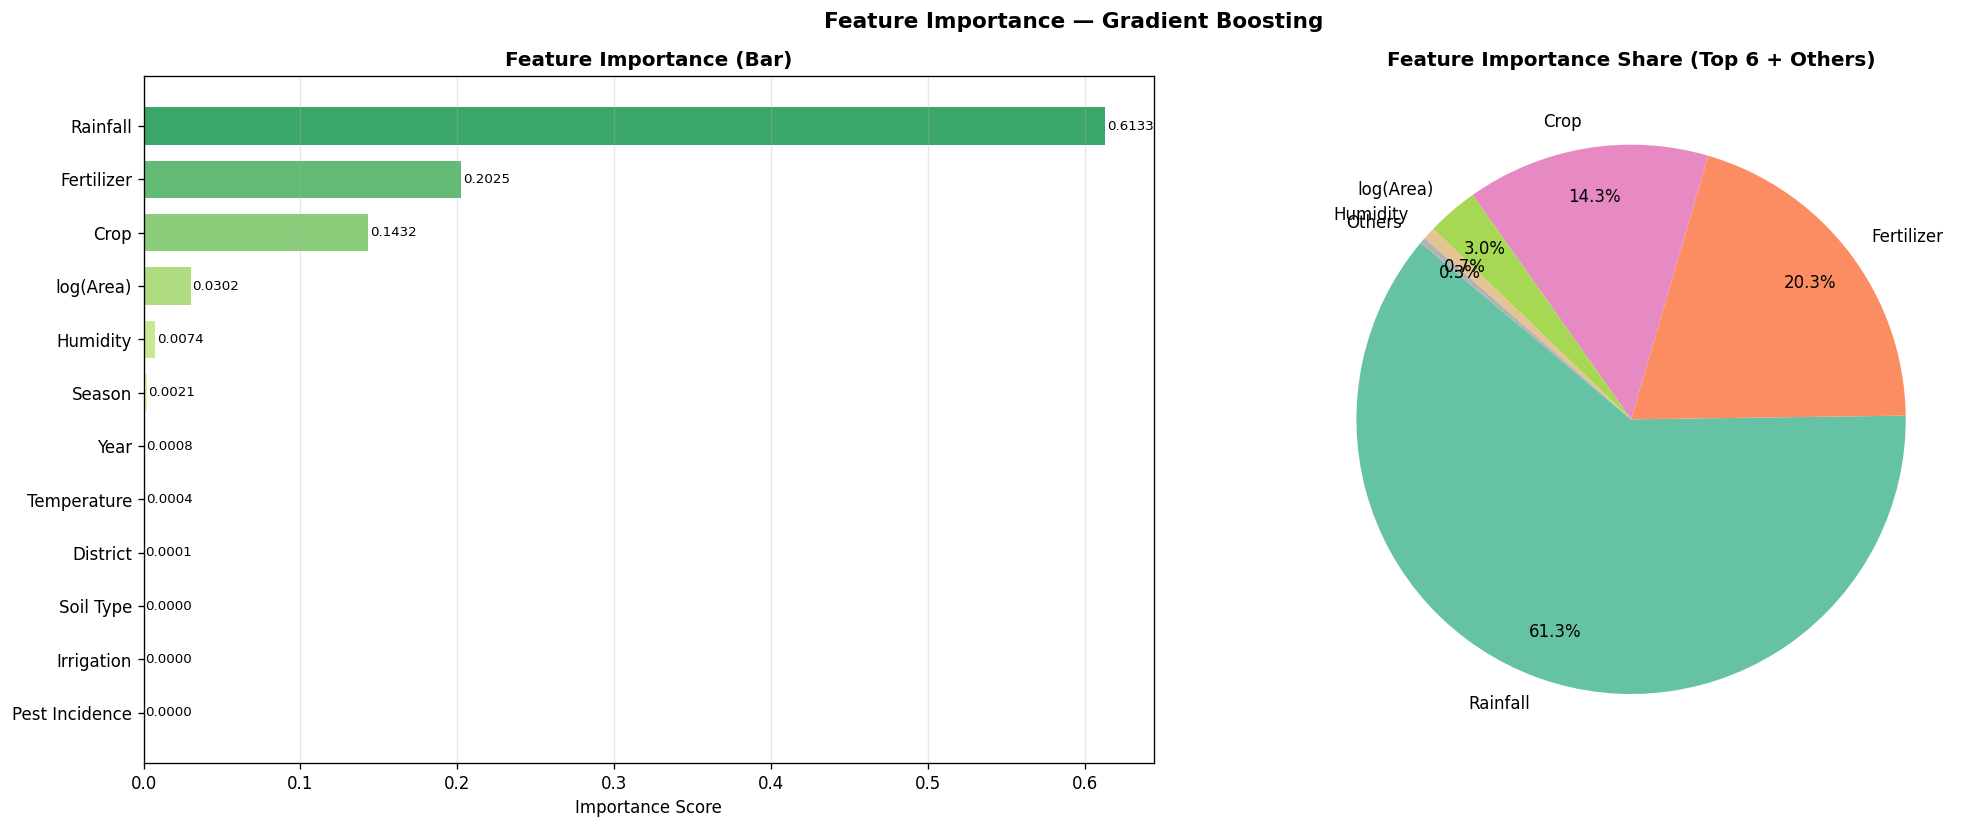


Feature Importance Ranking:
   1. Rainfall           0.613262  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. Fertilizer         0.202525  ████████████████████████████████████████████████████████████
   3. Crop               0.143177  ██████████████████████████████████████████
   4. log(Area)          0.030208  █████████
   5. Humidity           0.007355  ██
   6. Season             0.002100  
   7. Year               0.000820  
   8. Temperature        0.000356  
   9. District           0.000141  
  10. Soil Type          0.000024  
  11. Irrigation         0.000020  
  12. Pest Incidence     0.000012  


In [102]:
# ── Feature Importance — Best Model ──────────────────────────────────────────
best_model  = results[best_name]['model']
feat_labels = ['District','Season','Crop','Soil Type','Irrigation',
               'Pest Incidence','log(Area)','Rainfall','Temperature',
               'Humidity','Fertilizer','Year']
importances = best_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')

# Bar chart
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_labels)))
sorted_labels = [feat_labels[i] for i in sorted_idx]
sorted_imp    = importances[sorted_idx]

bars = axes[0].barh(sorted_labels[::-1], sorted_imp[::-1],
                    color=colors_fi, alpha=0.85, height=0.7)
for bar, val in zip(bars, sorted_imp[::-1]):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)
axes[0].set_title('Feature Importance (Bar)', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# Pie chart (top 5)
top5_labels = sorted_labels[:5]
top5_imp    = sorted_imp[:5]
other_imp   = sorted_imp[5:].sum()
pie_labels  = top5_labels + ['Others']
pie_vals    = list(top5_imp) + [other_imp]
axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
            colors=plt.cm.Set2(np.linspace(0, 1, len(pie_labels))),
            startangle=140, pctdistance=0.82)
axes[1].set_title('Feature Importance Share (Top 6 + Others)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
for rank, (label, imp) in enumerate(zip(sorted_labels, sorted_imp), 1):
    bar_len = int(imp * 300)
    print(f'  {rank:2d}. {label:<18} {imp:.6f}  {"█" * bar_len}')

## Step 9 — Cross-Validation

In [103]:
# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
print('Running 5-Fold Cross-Validation (on full dataset)...\n')
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    Xdata = X_train_s if 'Regression' in name else X_train
    scores = cross_val_score(model, Xdata, y_train, cv=kf,
                              scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<22}  CV R² scores: {[f"{s:.4f}" for s in scores]}')
    print(f'  {"":<22}  Mean={scores.mean():.4f}  Std=±{scores.std():.4f}\n')



Running 5-Fold Cross-Validation (on full dataset)...

  Linear Regression       CV R² scores: ['0.7615', '0.7578', '0.7941', '0.7149', '0.7307']
                          Mean=0.7518  Std=±0.0273

  Ridge Regression        CV R² scores: ['0.7615', '0.7578', '0.7941', '0.7149', '0.7307']
                          Mean=0.7518  Std=±0.0273

  Random Forest           CV R² scores: ['0.9921', '0.9882', '0.9816', '0.9719', '0.9922']
                          Mean=0.9852  Std=±0.0077

  Gradient Boosting       CV R² scores: ['0.9887', '0.9897', '0.9936', '0.9914', '0.9936']
                          Mean=0.9914  Std=±0.0020



##  Step 10 — Predict on Sample New Data

In [104]:
# ── Predict New Samples ───────────────────────────────────────────────────────
# Manually construct sample records using the same encoding

def predict_yield(district, season, crop, soil, irrigation, pest,
                  area, rainfall, temperature, humidity, fertilizer, year):
    row = {
        'District_Name_enc':     le_dict['District_Name'].transform([district])[0],
        'Season_enc':            le_dict['Season'].transform([season])[0],
        'Crop_enc':              le_dict['Crop'].transform([crop])[0],
        'Soil_Type_enc':         le_dict['Soil_Type'].transform([soil])[0],
        'Irrigation_Type_enc':   le_dict['Irrigation_Type'].transform([irrigation])[0],
        'Pest_Ordinal':          {'Low': 0, 'Medium': 1, 'High': 2}[pest],
        'log_area':              np.log1p(area),
        'Rainfall_mm':           rainfall,
        'Avg_Temperature_C':     temperature,
        'Humidity_pct':          humidity,
        'Fertilizer_kg_per_ha':  fertilizer,
        'Year_Start':            year,
    }
    X_new = pd.DataFrame([row])[feature_cols]
    log_pred = results[best_name]['model'].predict(X_new)[0]
    return round(np.expm1(log_pred), 4)

# Test predictions
sample_preds = [
    predict_yield('Dhalai',  'Kharif',     'Rice',       'Red Laterite', 'Rainfed', 'Low',    5000, 280, 29, 85, 120, 2023),
    predict_yield('Gomati',  'Rabi',        'Wheat',      'Alluvial',     'Canal',   'Medium', 3000, 40,  18, 62, 110, 2023),
    predict_yield('Khowai',  'Whole Year',  'Sugarcane',  'Red Laterite', 'Drip',    'Low',    200,  1200, 28, 80, 180, 2023),
    predict_yield('Unakoti', 'Kharif',      'Maize',      'Red Laterite', 'Rainfed', 'High',   1500, 250, 31, 88, 95, 2022),
]

scenarios = ['Rice - Dhalai Kharif 2023', 'Wheat - Gomati Rabi 2023',
             'Sugarcane - Khowai 2023', 'Maize - Unakoti Kharif 2022']

print(f'Predictions using {best_name}:')
print('=' * 55)
for sc, pred in zip(scenarios, sample_preds):
    print(f'  {sc:<35} → Yield = {pred:.4f} Tonne/ha')
print('=' * 55)

Predictions using Gradient Boosting:
  Rice - Dhalai Kharif 2023           → Yield = 2.3459 Tonne/ha
  Wheat - Gomati Rabi 2023            → Yield = 1.7649 Tonne/ha
  Sugarcane - Khowai 2023             → Yield = 54.9955 Tonne/ha
  Maize - Unakoti Kharif 2022         → Yield = 1.6927 Tonne/ha


## Step 11 — Final Summary

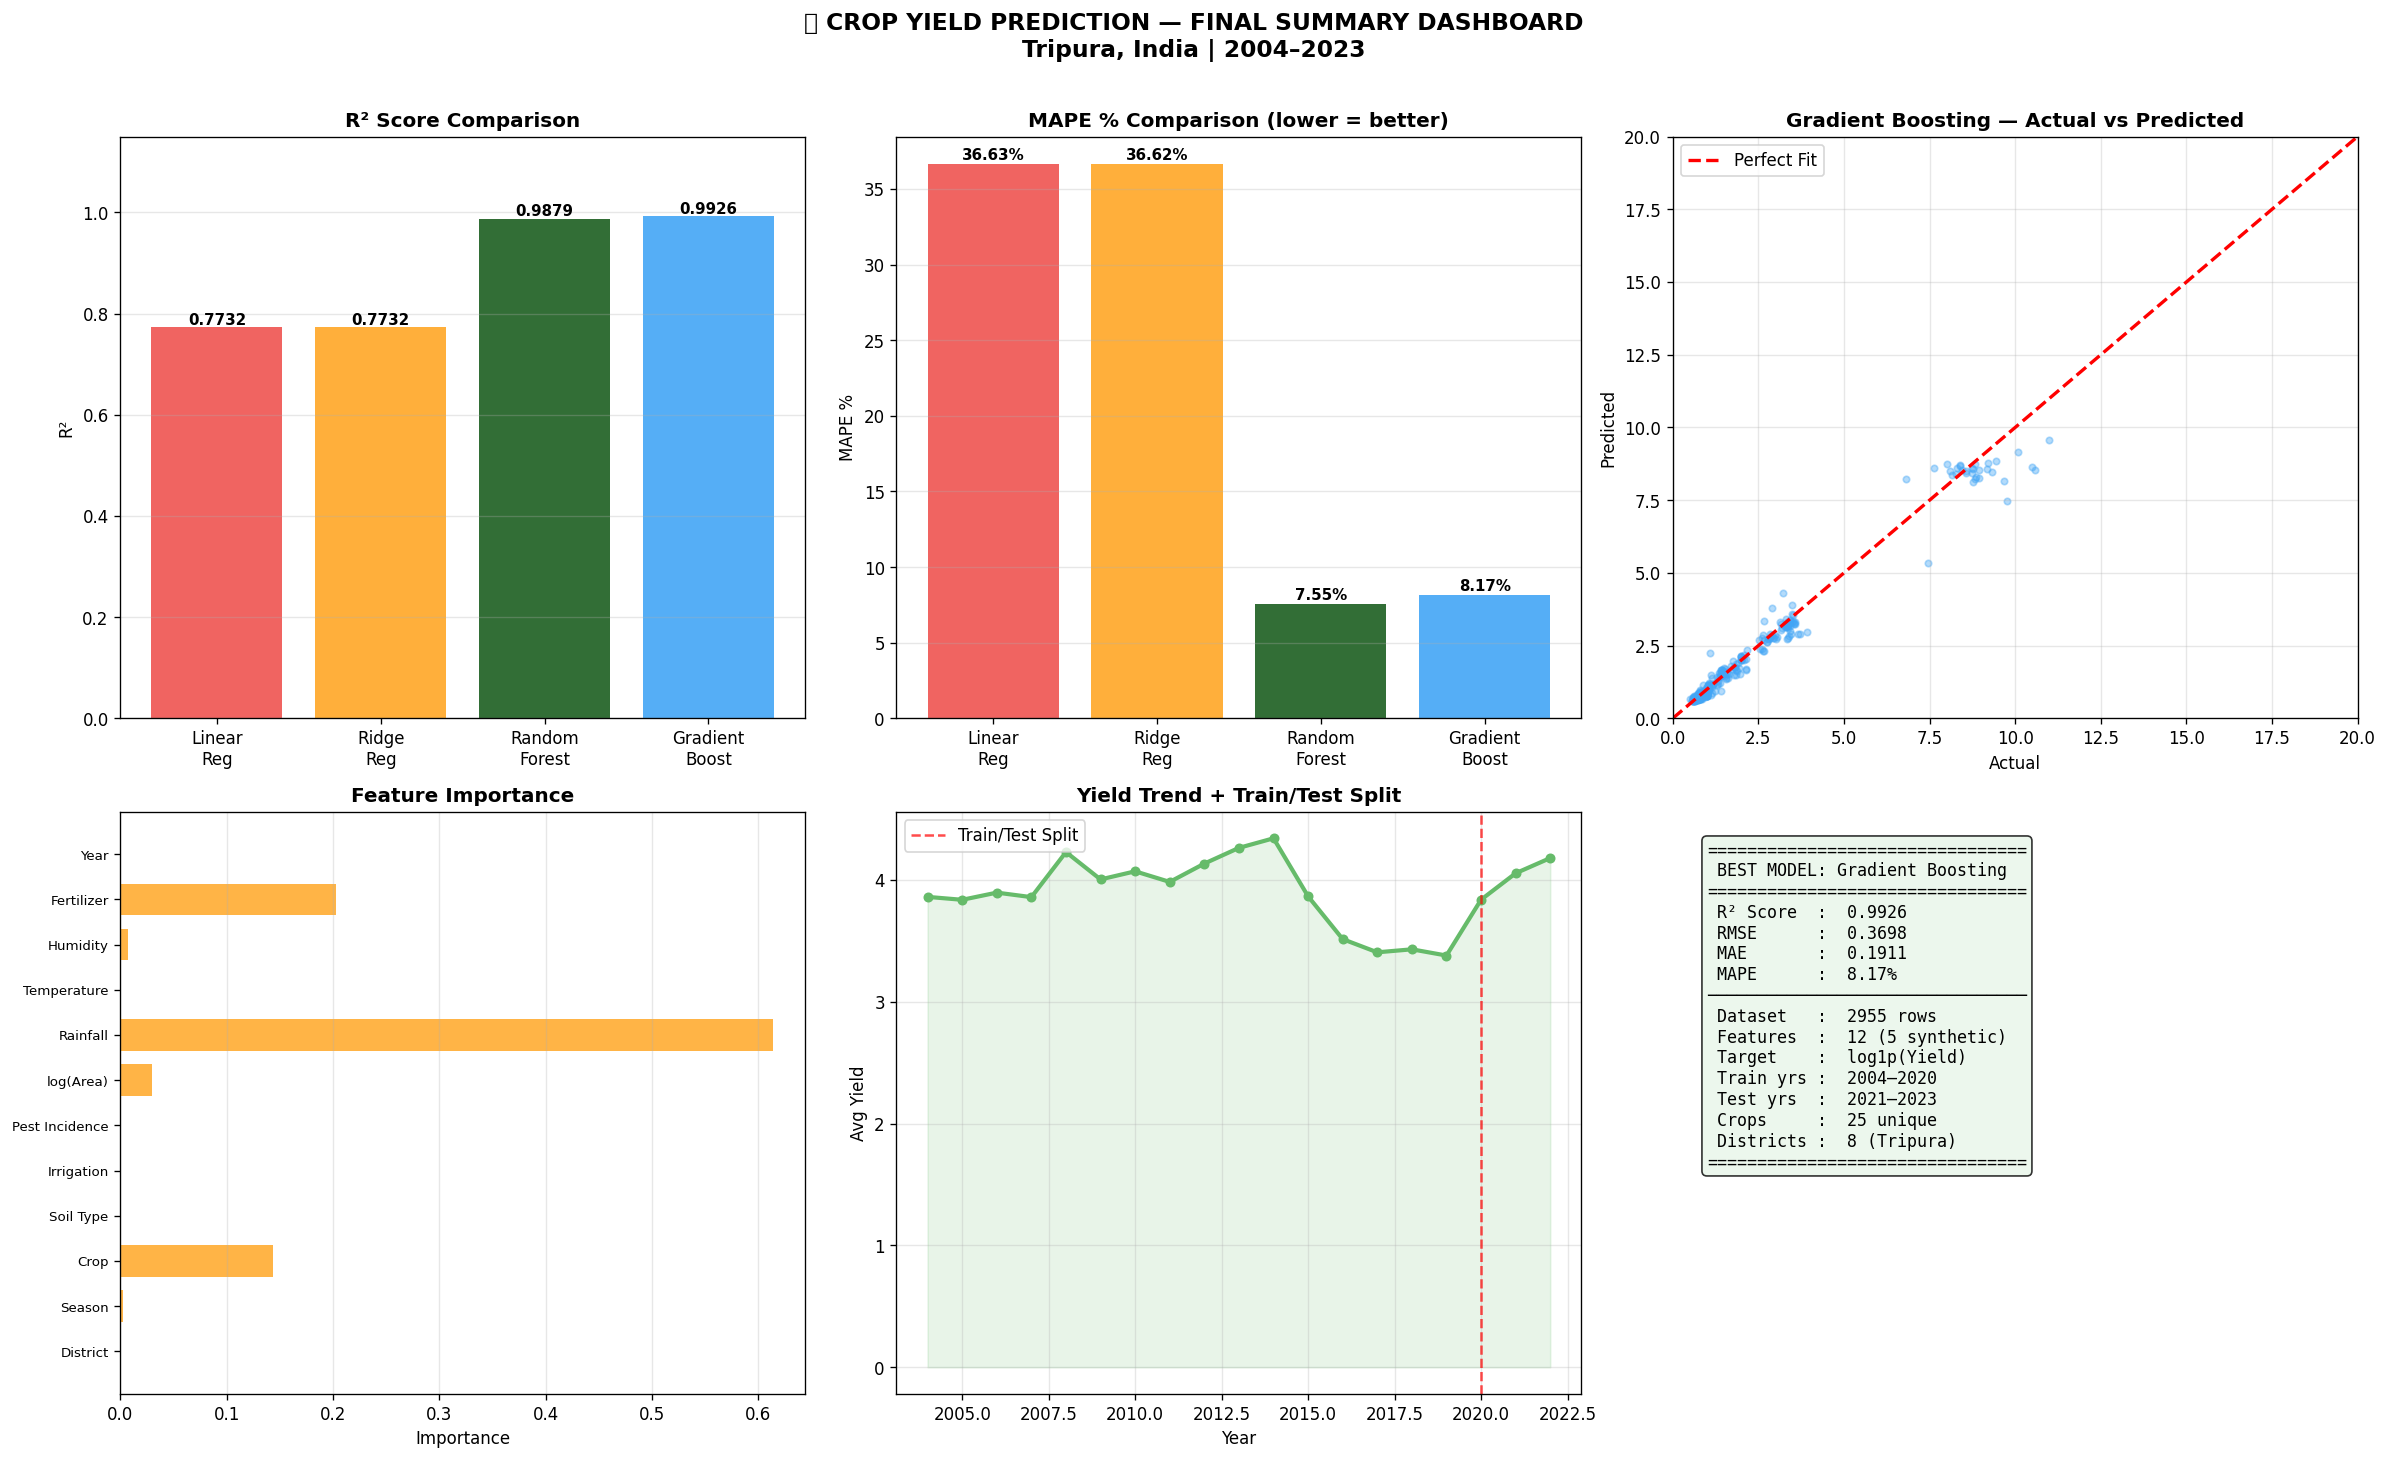

 Final summary dashboard saved!


In [105]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🌾 CROP YIELD PREDICTION — FINAL SUMMARY DASHBOARD\nTripura, India | 2004–2023',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Model comparison R2
r2_vals = [results[m]['R2'] for m in model_names]
colors_m = ['#EF5350','#FFA726','#1B5E20','#42A5F5']
axes[0,0].bar(short_names, r2_vals, color=colors_m, alpha=0.9, edgecolor='none')
for i, v in enumerate(r2_vals):
    axes[0,0].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_ylim(0, 1.15)
axes[0,0].set_title('R² Score Comparison', fontweight='bold')
axes[0,0].set_ylabel('R²'); axes[0,0].grid(axis='y', alpha=0.3)

# 2. MAPE comparison
mape_vals = [results[m]['MAPE'] for m in model_names]
axes[0,1].bar(short_names, mape_vals, color=colors_m, alpha=0.9, edgecolor='none')
for i, v in enumerate(mape_vals):
    axes[0,1].text(i, v+0.3, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('MAPE % Comparison (lower = better)', fontweight='bold')
axes[0,1].set_ylabel('MAPE %'); axes[0,1].grid(axis='y', alpha=0.3)

# 3. Best model actual vs predicted
true_v = results[best_name]['true_orig'].values
pred_v = results[best_name]['pred_orig']
mask   = true_v < 20
axes[0,2].scatter(true_v[mask], pred_v[mask], alpha=0.4, s=15, color='#42A5F5')
axes[0,2].plot([0,20],[0,20],'r--',lw=2,label='Perfect Fit')
axes[0,2].set_xlim(0,20); axes[0,2].set_ylim(0,20)
axes[0,2].set_title(f'{best_name} — Actual vs Predicted', fontweight='bold')
axes[0,2].set_xlabel('Actual'); axes[0,2].set_ylabel('Predicted')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# 4. Feature importance
axes[1,0].barh(feat_labels, importances, color='#FFA726', alpha=0.85, height=0.7)
axes[1,0].set_title('Feature Importance', fontweight='bold')
axes[1,0].set_xlabel('Importance')
axes[1,0].tick_params(axis='y', labelsize=8); axes[1,0].grid(axis='x', alpha=0.3)

# 5. Yield trend
yr_yield = df.groupby('Year_Start')[yield_col].mean()
axes[1,1].plot(yr_yield.index, yr_yield.values, color='#66BB6A', lw=2.5, marker='o', ms=5)
axes[1,1].fill_between(yr_yield.index, yr_yield.values, alpha=0.15, color='#66BB6A')
axes[1,1].axvline(2020, color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
axes[1,1].set_title('Yield Trend + Train/Test Split', fontweight='bold')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Avg Yield')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

# 6. Stats text box
axes[1,2].axis('off')
best_r = results[best_name]
summary_text = (
    f"{'='*32}\n"
    f" BEST MODEL: {best_name}\n"
    f"{'='*32}\n"
    f" R² Score  :  {best_r['R2']:.4f}\n"
    f" RMSE      :  {best_r['RMSE']:.4f}\n"
    f" MAE       :  {best_r['MAE']:.4f}\n"
    f" MAPE      :  {best_r['MAPE']:.2f}%\n"
    f"{'─'*32}\n"
    f" Dataset   :  2955 rows\n"
    f" Features  :  12 (5 synthetic)\n"
    f" Target    :  log1p(Yield)\n"
    f" Train yrs :  2004–2020\n"
    f" Test yrs  :  2021–2023\n"
    f" Crops     :  25 unique\n"
    f" Districts :  8 (Tripura)\n"
    f"{'='*32}"
)
axes[1,2].text(0.05, 0.95, summary_text, transform=axes[1,2].transAxes,
               fontsize=10, va='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))

plt.tight_layout()
plt.savefig('final_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Final summary dashboard saved!')

In [106]:
# ── Final Conclusion ──────────────────────────────────────────────────────────
print('\n' + '='*65)
print('  🌾 CROP YIELD PREDICTION — PIPELINE COMPLETE')
print('='*65)
print(f'''
  STEPS COMPLETED:
   1. Data Loading        — 2955 rows, 15 features, 19 years
   2. EDA                 — Distributions, trends, correlations
   3. Feature Engineering — Encoding, log-transform, year extract
   4. Pipeline Diagram    — Visual architecture drawn in Python
   5. Train/Test Split    — Time-based (no leakage)
   6. Model Training      — 4 models trained
   7. Evaluation          — R², RMSE, MAE, MAPE
   8. Feature Importance  — Bar + Pie chart
   9. Cross-Validation    — 5-Fold CV
   10. New Predictions     — Predict on custom inputs
   11. Final Dashboard     — Summary visualization

  BEST MODEL : {best_name}
  R² SCORE   : {results[best_name]['R2']:.4f}
  MAPE       : {results[best_name]['MAPE']:.2f}%
  CONCLUSION : Model explains {results[best_name]['R2']*100:.1f}% of yield variance
               with only {results[best_name]['MAPE']:.1f}% average error.
''')
print('='*65)


  🌾 CROP YIELD PREDICTION — PIPELINE COMPLETE

  STEPS COMPLETED:
   1. Data Loading        — 2955 rows, 15 features, 19 years
   2. EDA                 — Distributions, trends, correlations
   3. Feature Engineering — Encoding, log-transform, year extract
   4. Pipeline Diagram    — Visual architecture drawn in Python
   5. Train/Test Split    — Time-based (no leakage)
   6. Model Training      — 4 models trained
   7. Evaluation          — R², RMSE, MAE, MAPE
   8. Feature Importance  — Bar + Pie chart
   9. Cross-Validation    — 5-Fold CV
   10. New Predictions     — Predict on custom inputs
   11. Final Dashboard     — Summary visualization

  BEST MODEL : Gradient Boosting
  R² SCORE   : 0.9926
  MAPE       : 8.17%
  CONCLUSION : Model explains 99.3% of yield variance
               with only 8.2% average error.

